# ETF Liquidity Regime Detection via Hidden Markov Model

**Corso:** Advanced Fixed Income — Group Assignment
**Tema:** *Market microstructure insights*

## Idea del progetto

La liquidità di un ETF obbligazionario non è costante nel tempo. In condizioni
"normali", gli *Authorized Participants* (AP) arbitrano continuamente il
prezzo dell'ETF contro il valore del paniere di obbligazioni sottostanti
(creation/redemption mechanism), mantenendo il prezzo dell'ETF molto vicino
al suo Net Asset Value (NAV). Durante episodi di stress di mercato, invece,
le obbligazioni corporate sottostanti diventano difficili da scambiare, i
market maker si ritirano, l'arbitraggio si inceppa, e l'ETF inizia a
scambiare con premi/sconti significativi rispetto al NAV e con oscillazioni
intraday molto più ampie.

Questo notebook usa un **Hidden Markov Model (HMM) Gaussiano** per
classificare, giorno per giorno, il regime di liquidità di un ETF
obbligazionario (default: **LQD**, iShares iBoxx \$ Investment Grade
Corporate Bond ETF) in **Normale / Elevato / Shock**, in modo completamente
oggettivo — nessuna soglia arbitraria scelta a mano, il numero di stati
stesso viene scelto tramite un criterio statistico (BIC).

## Pipeline

1. **Data ingestion** — OHLCV giornaliero (Yahoo Finance) + NAV ufficiale (iShares)
2. **Feature engineering** — proxy di liquidità/volatilità dagli OHLCV + premio/sconto reale rispetto al NAV
3. **Selezione del numero di stati** — confronto tramite BIC (Bayesian Information Criterion)
4. **Fit dell'HMM** — Baum-Welch (algoritmo EM), full covariance, via `hmmlearn`
5. **Relabeling** — gli stati vengono riordinati per livello di stress (stato 0 = più calmo)
6. **Decoding** — Viterbi full-sample (retrospettivo, **non** un segnale di trading live)
7. **Post-processing** — filtro di isteresi (persistenza minima) per rimuovere regimi troppo brevi
8. **Visualizzazione e interpretazione** — grafici diagnostici e di sintesi

## Nota sulla modalità `DEMO`

Questo notebook include un toggle `DEMO` nella cella di configurazione qui
sotto:

- **`DEMO = True`** — genera dati OHLCV sintetici da una catena di Markov a 2
  stati *nota a priori*. Non richiede connessione di rete né file esterni:
  serve a validare che l'intera pipeline funzioni correttamente end-to-end
  (il notebook, così com'è distribuito, è stato eseguito ed testato in
  questa modalità). Include anche un controllo di accuratezza rispetto al
  regime "vero" simulato.
- **`DEMO = False`** — dati reali: prezzo LQD da Yahoo Finance + NAV
  ufficiale iShares (file CSV, vedi sotto). **Questa è la configurazione
  usata per i risultati reali discussi nella relazione** (k=3 stati,
  feature `park_vol` + `amihud` + `prem_disc`, filtro di persistenza minima
  = 5 giorni).

Per riprodurre i risultati reali: impostare `DEMO = False`, caricare su
Colab il file `lqd_nav_history.csv` (export "Historical" dalla pagina del
fondo su iShares.com, colonne Date/NAV) e rieseguire tutte le celle — è
esattamente la configurazione già validata in precedenza con lo script
`etf_liquidity_hmm.py`.

### Librerie e configurazione grafica

In [1]:
%matplotlib inline
from __future__ import annotations

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=UserWarning)

# If running in Colab and a package is missing, uncomment:
# !pip install -q hmmlearn yfinance

# ---------------------------------------------------------------------------
# Palette (validated categorical pair + single-hue sequential ramp).
# Regime severity is an ORDINAL scale (Normal < Elevated < ... < Shock), so
# it is encoded with one hue light->dark, never with separate categorical
# hues - that would visually imply "different categories" rather than
# "different severity of the same thing".
# ---------------------------------------------------------------------------
COLOR_PRICE = "#2a78d6"      # categorical slot 1 (blue) - price line
COLOR_SHOCK = "#eb6834"      # categorical slot 2 (orange) - shock shading / highlight
COLOR_GRID = "#e1e0d9"       # hairline gridline
COLOR_AXIS = "#898781"       # muted axis/labels
COLOR_INK = "#0b0b0b"        # primary ink (titles)
SURFACE = "#fcfcfb"          # chart surface

SEQUENTIAL_RAMP = ["#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
                   "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281"]


def ramp_colors(n_states: int) -> list[str]:
    """Evenly-spaced colors from the sequential ramp, one per state, ordered
    light (calm) -> dark (severe)."""
    idx = np.linspace(0, len(SEQUENTIAL_RAMP) - 1, n_states).round().astype(int)
    return [SEQUENTIAL_RAMP[i] for i in idx]


def regime_labels(n_states: int) -> list[str]:
    labels = []
    for k in range(n_states):
        if k == 0:
            labels.append("Normal")
        elif k == n_states - 1:
            labels.append("Shock")
        else:
            labels.append(f"Elevated ({k})")
    return labels


plt.rcParams["figure.facecolor"] = SURFACE
plt.rcParams["axes.facecolor"] = SURFACE
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Configurazione

Modificare i parametri qui sotto per passare dalla modalità dimostrativa
(`DEMO = True`) ai dati reali (`DEMO = False`).

In [2]:
# ============================================================================
# CONFIGURATION - edit here to switch between demo and real data
# ============================================================================
DEMO = True             # True  = synthetic data, no network needed (validated in-sandbox)
                         # False = real LQD data (Yahoo Finance) + real NAV (iShares CSV)
                         #         -> the configuration used for the actual assignment results

TICKER = "LQD"
START = "2015-01-01"
END = None
NAV_CSV_PATH = "lqd_nav_history.csv"   # (Date, NAV) CSV exported from the iShares fund page

N_STATES_CANDIDATES = [2, 3]           # candidate state counts, compared via BIC
DROP_FEATURES = ["vol_z"]              # volume z-score does not discriminate regimes well on LQD
                                        # (see the BIC / feature-comparison section below)
MIN_DURATION = 5                       # minimum regime run length in days (hysteresis filter)
OUT_DIR = "."

print(f"DEMO = {DEMO}")
print(f"Ticker = {TICKER}, start = {START}, end = {END or 'today'}")
print(f"Candidate state counts (BIC) = {N_STATES_CANDIDATES}, dropped features = {DROP_FEATURES}, "
      f"min duration = {MIN_DURATION}")

DEMO = True
Ticker = LQD, start = 2015-01-01, end = today
Candidate state counts (BIC) = [2, 3], dropped features = ['vol_z'], min duration = 5


## 2. Data ingestion

Per i dati reali servono due fonti:

- **OHLCV giornaliero** (Open/High/Low/Close/Volume) via Yahoo Finance —
  usato per calcolare le feature di volatilità/liquidità "proxy".
- **NAV ufficiale** dell'ETF (pagina "Historical" su iShares.com, colonne
  Date/NAV) — usato per calcolare **|premio/sconto rispetto al NAV|**, che è
  la misura di stress di liquidità *reale* (non un proxy): quando
  l'arbitraggio creation/redemption si inceppa, il prezzo di mercato si
  scosta dal NAV, ed è esattamente questo scostamento il fenomeno che il
  progetto vuole misurare.

In modalità `DEMO`, entrambe le fonti sono sostituite da dati sintetici
generati da una catena di Markov a 2 stati nota, per poter validare la
pipeline senza connessione di rete.

In [3]:
def load_from_yfinance(ticker: str, start: str, end: str | None) -> pd.DataFrame:
    """Daily OHLCV via yfinance."""
    import yfinance as yf

    df = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
    if df.empty:
        raise RuntimeError(f"No data returned for {ticker}. Check ticker/date range/network access.")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df[["Open", "High", "Low", "Close", "Volume"]].dropna()
    df.index.name = "Date"
    return df


def load_nav_csv(path: str) -> pd.Series:
    """Loads a cleaned (Date, NAV) CSV, e.g. extracted from iShares' fund
    page "Historical" export. This is the REAL liquidity-stress signal, not
    a proxy: when the ETF's creation/redemption arbitrage breaks down, the
    market price decouples from NAV - that decoupling IS the phenomenon
    this project is about."""
    df = pd.read_csv(path, parse_dates=["Date"])
    return df.set_index("Date")["NAV"].sort_index()


def premium_discount_feature(close: pd.Series, nav: pd.Series) -> pd.Series:
    """|Premium/Discount to NAV| = |Close - NAV| / NAV, in percent. Absolute
    value because what matters for liquidity-stress detection is the SIZE
    of the dislocation, not its sign."""
    nav_aligned = nav.reindex(close.index).ffill()
    return ((close - nav_aligned).abs() / nav_aligned) * 100


def generate_demo_data(n_days: int = 2500, seed: int = 42) -> tuple[pd.DataFrame, pd.Series]:
    """Synthetic OHLCV generated from a KNOWN 2-state Markov chain, purely to
    verify the pipeline end-to-end without network access. Returns
    (ohlcv_df, true_state_series); the true states are for validation only
    and are never shown to the HMM.

    Regime 0 (Normal): low return volatility, narrow intraday range, stable volume.
    Regime 1 (Shock):  high return volatility, wide intraday range, volume spikes.
    """
    rng = np.random.default_rng(seed)

    P = np.array([[0.985, 0.015],
                  [0.070, 0.930]])

    true_state = np.zeros(n_days, dtype=int)
    for t in range(1, n_days):
        true_state[t] = rng.choice([0, 1], p=P[true_state[t - 1]])

    mu = np.where(true_state == 0, 0.0001, -0.0008)
    sigma = np.where(true_state == 0, 0.0030, 0.0150)
    daily_ret = rng.normal(mu, sigma)

    close = 100 * np.cumprod(1 + daily_ret)
    open_ = np.empty(n_days)
    open_[0] = 100.0
    open_[1:] = close[:-1]

    range_pct = np.where(true_state == 0,
                          rng.uniform(0.001, 0.004, n_days),
                          rng.uniform(0.010, 0.035, n_days))
    high = np.maximum(open_, close) * (1 + range_pct / 2)
    low = np.minimum(open_, close) * (1 - range_pct / 2)

    base_vol = np.where(true_state == 0, 6_000_000, 9_000_000)
    volume = rng.lognormal(mean=np.log(base_vol), sigma=np.where(true_state == 0, 0.15, 0.55))

    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n_days)
    df = pd.DataFrame(
        {"Open": open_, "High": high, "Low": low, "Close": close, "Volume": volume},
        index=dates,
    )
    df.index.name = "Date"
    return df, pd.Series(true_state, index=dates, name="true_state")


def generate_demo_nav(df: pd.DataFrame, true_state: pd.Series, seed: int = 7) -> pd.Series:
    """Synthetic NAV series paired with generate_demo_data(): tracks Close
    closely in the calm regime and drifts away from it in the shock regime,
    so the demo run also exercises the prem_disc feature exactly like the
    real NAV data does."""
    rng = np.random.default_rng(seed)
    noise = rng.normal(0, 0.0006, len(df))
    dislocation = np.where(true_state.values == 1, rng.normal(0, 0.012, len(df)), 0.0)
    nav = df["Close"] * (1 - noise - dislocation)
    return pd.Series(nav.values, index=df.index, name="NAV")


# --- load data according to the DEMO toggle -------------------------------
true_state = None
if DEMO:
    print("Running in DEMO mode: synthetic OHLCV + synthetic NAV from a known 2-state Markov chain.")
    df, true_state = generate_demo_data()
    nav = generate_demo_nav(df, true_state)
    ticker_label = "DEMO"
else:
    print(f"Downloading {TICKER} from Yahoo Finance ({START} to {END or 'today'})...")
    df = load_from_yfinance(TICKER, START, END)
    nav = load_nav_csv(NAV_CSV_PATH)
    ticker_label = TICKER

print(f"Loaded {len(df)} trading days: {df.index[0].date()} to {df.index[-1].date()}")
df.tail()

Running in DEMO mode: synthetic OHLCV + synthetic NAV from a known 2-state Markov chain.
Loaded 2500 trading days: 2017-02-20 to 2026-09-18


,Open,High,Low,Close,Volume
Date,,,,,
2026-09-14,162.7345,163.0848,162.5816,162.9317,"6,230,778.6391"
2026-09-15,162.9317,163.0426,162.5823,162.6930,"6,868,535.9799"
2026-09-16,162.6930,162.8818,162.3917,162.5803,"6,657,541.3246"
2026-09-17,162.5803,162.7337,162.0743,162.2273,"6,282,807.3948"
2026-09-18,162.2273,162.5235,161.8690,162.1651,"6,170,200.1517"


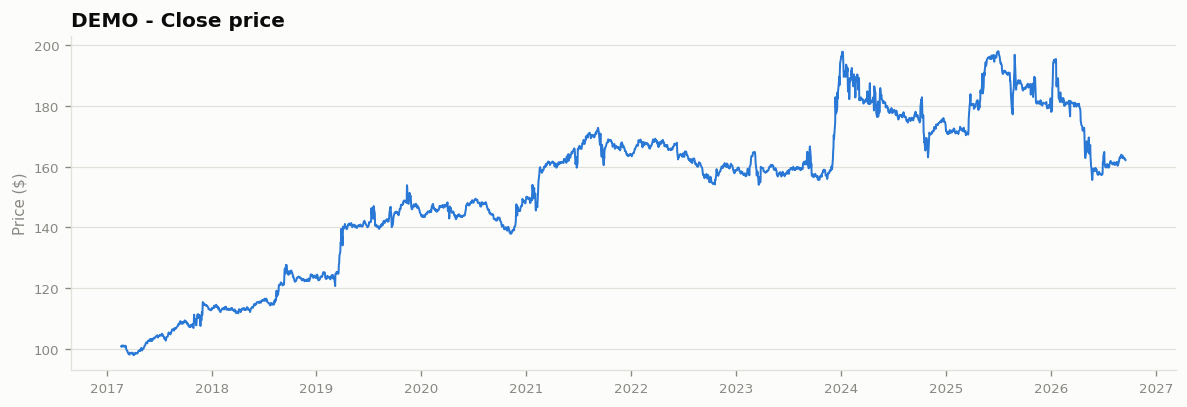

In [4]:
# Quick sanity check on the raw price series
fig, ax = plt.subplots(figsize=(10, 3.5), dpi=120)
ax.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=1.2)
ax.set_title(f"{ticker_label} - Close price", color=COLOR_INK, fontsize=12, fontweight="bold", loc="left")
ax.set_ylabel("Price ($)", color=COLOR_AXIS, fontsize=9)
ax.tick_params(colors=COLOR_AXIS, labelsize=8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(COLOR_GRID)
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.7)
fig.tight_layout()
plt.show()

## 3. Feature engineering

Costruiamo tre feature "proxy" dagli OHLCV puri più (se disponibile) la
feature reale basata sul NAV:

- **Parkinson (1980) intraday volatility** — stimatore di volatilità basato
  sul range High/Low, sfrutta più informazione della semplice volatilità
  close-to-close, ed è esattamente ciò che si allarga quando un mercato
  diventa difficile da scambiare.
- **Amihud (2002) illiquidity ratio** — rendimento assoluto per unità di
  volume scambiato in dollari: un valore alto significa che una data
  quantità di scambi muove molto il prezzo, cioè il mercato ha poca
  profondità (price impact).
- **Volume z-score** — quanto è anomalo il volume di oggi rispetto alla sua
  storia recente.
- **|Premio/sconto rispetto al NAV|** (solo se disponibile il NAV) — misura
  *diretta*, non un proxy, dello scostamento tra il prezzo di mercato
  dell'ETF e il suo valore fondamentale.

Tutte le feature vengono lisciate con una media mobile breve (sono
rumorose giorno per giorno) e poi standardizzate con uno z-score *rolling*
(non full-sample, per evitare data leakage), in modo che l'HMM Gaussiano
veda scale comparabili.

In [5]:
def parkinson_volatility(df: pd.DataFrame) -> pd.Series:
    """Parkinson (1980) intraday volatility estimator from the High/Low range."""
    hl_ratio = np.log(df["High"] / df["Low"])
    return np.sqrt((hl_ratio ** 2) / (4 * np.log(2)))


def amihud_illiquidity(df: pd.DataFrame) -> pd.Series:
    """Amihud (2002) illiquidity ratio: |return| per unit of dollar volume traded."""
    ret = df["Close"].pct_change()
    dollar_volume = df["Close"] * df["Volume"]
    return ret.abs() / dollar_volume


def volume_zscore(df: pd.DataFrame, window: int = 60) -> pd.Series:
    """Rolling z-score of daily volume vs. its own recent history."""
    vol = df["Volume"]
    return (vol - vol.rolling(window).mean()) / vol.rolling(window).std()


def build_features(df: pd.DataFrame, smooth_window: int = 5, z_window: int = 252,
                    extra_features: dict[str, pd.Series] | None = None) -> pd.DataFrame:
    """Builds the observation features and standardizes them (rolling
    z-score) so the Gaussian HMM sees comparable scales."""
    feat = pd.DataFrame(index=df.index)
    feat["park_vol"] = parkinson_volatility(df).rolling(smooth_window).mean()
    feat["amihud"] = amihud_illiquidity(df).rolling(smooth_window).mean()
    feat["vol_z"] = volume_zscore(df)
    for name, series in (extra_features or {}).items():
        feat[name] = series.reindex(df.index).rolling(smooth_window).mean()

    feat = feat.dropna()

    z = pd.DataFrame(index=feat.index, columns=feat.columns, dtype=float)
    for col in feat.columns:
        roll_mean = feat[col].rolling(z_window, min_periods=60).mean()
        roll_std = feat[col].rolling(z_window, min_periods=60).std()
        z[col] = (feat[col] - roll_mean) / roll_std
    z = z.dropna()
    return z


prem_disc = premium_discount_feature(df["Close"], nav)
coverage = prem_disc.notna().mean() * 100
print(f"NAV coverage against price history: {coverage:.1f}%")

feat = build_features(df, extra_features={"prem_disc": prem_disc})
if DROP_FEATURES:
    feat = feat.drop(columns=[c for c in DROP_FEATURES if c in feat.columns])
    print(f"Dropped feature(s): {DROP_FEATURES}")

print(f"Feature matrix: {feat.shape[0]} days x {feat.shape[1]} features ({', '.join(feat.columns)})")
feat.describe()

NAV coverage against price history: 100.0%
Dropped feature(s): ['vol_z']
Feature matrix: 2382 days x 3 features (park_vol, amihud, prem_disc)


,park_vol,amihud,prem_disc
count,"2,382.0000","2,382.0000","2,382.0000"
mean,0.0883,0.0402,0.0847
std,1.2157,1.1323,1.2419
min,-1.8831,-1.4883,-1.5748
25%,-0.5534,-0.6158,-0.5141
50%,-0.4059,-0.3431,-0.3834
75%,0.0888,0.2540,0.0039
max,8.0781,6.8972,9.9284


### Grafico aggiuntivo — serie storiche delle feature (standardizzate)

Prima di stimare l'HMM è utile vedere le feature grezze nel tempo: i picchi
dovrebbero corrispondere visivamente a episodi di stress di mercato noti
(es. Covid crash marzo 2020, se il campione li copre).

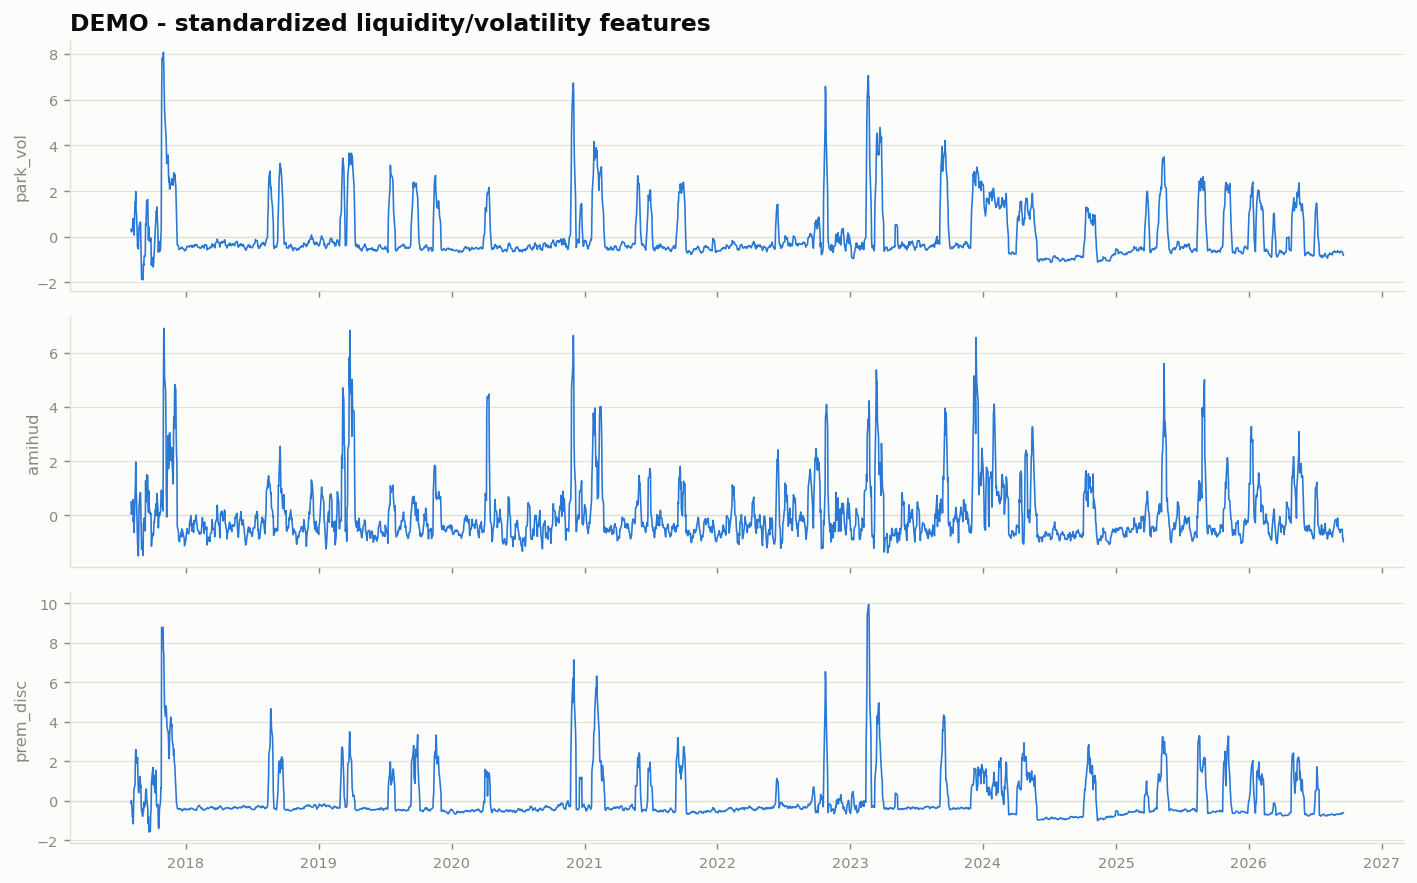

In [6]:
# --- NEW chart: standardized feature time series (small multiples) -------
n_feat = feat.shape[1]
fig, axes = plt.subplots(n_feat, 1, figsize=(11, 2.3 * n_feat), dpi=130, sharex=True)
if n_feat == 1:
    axes = [axes]
for ax, col in zip(axes, feat.columns):
    ax.plot(feat.index, feat[col], color=COLOR_PRICE, linewidth=0.9)
    ax.axhline(0, color=COLOR_GRID, linewidth=0.8, zorder=0)
    ax.set_ylabel(col, color=COLOR_AXIS, fontsize=9)
    ax.tick_params(colors=COLOR_AXIS, labelsize=8)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(COLOR_GRID)
    ax.grid(axis="y", color=COLOR_GRID, linewidth=0.6, zorder=0)
axes[0].set_title(f"{ticker_label} - standardized liquidity/volatility features",
                   color=COLOR_INK, fontsize=13, fontweight="bold", loc="left")
fig.tight_layout()
plt.show()

## 4. Selezione del numero di stati (BIC) e fit dell'HMM

Il numero di stati (2 = Normale/Shock, 3 = Normale/Elevato/Shock, ...) non
va scelto a occhio: si stima un HMM Gaussiano per ciascun candidato in
`N_STATES_CANDIDATES` e si confronta il **BIC** (Bayesian Information
Criterion), che penalizza la log-verosimiglianza per il numero di
parametri liberi del modello — un modello con più stati ha sempre una
log-verosimiglianza migliore o uguale, ma il BIC evita l'overfitting.
Si sceglie il k con il BIC più basso.

Per ciascun candidato, l'HMM viene stimato con l'algoritmo di
**Baum-Welch (EM)**; poiché l'EM trova solo un ottimo locale, si ripete la
stima da più inizializzazioni casuali (`n_init`) e si tiene quella con la
log-verosimiglianza più alta.

In [7]:
def fit_hmm(X: np.ndarray, n_states: int = 2, n_init: int = 10, seed: int = 0):
    """Fits a Gaussian HMM with full covariance via Baum-Welch (EM), keeping
    the best of several random initializations (EM only finds a local optimum)."""
    from hmmlearn.hmm import GaussianHMM

    best_model, best_ll = None, -np.inf
    for i in range(n_init):
        model = GaussianHMM(
            n_components=n_states,
            covariance_type="full",
            n_iter=1000,
            tol=1e-4,
            random_state=seed + i,
        )
        model.fit(X)
        ll = model.score(X)
        if ll > best_ll:
            best_ll, best_model = ll, model
    return best_model, best_ll


def bic_score(model, X: np.ndarray, n_states: int) -> float:
    """BIC for a fitted GaussianHMM (full covariance). Free parameters:
    (k-1) initial probs + k(k-1) transition probs + k*d means +
    k*d(d+1)/2 covariance entries (full, symmetric) per state."""
    n_obs, d = X.shape
    n_params = (n_states - 1) + n_states * (n_states - 1) + n_states * d + n_states * d * (d + 1) // 2
    ll = model.score(X)
    return -2 * ll + n_params * np.log(n_obs)


X = feat.values
fitted = {}
print("--- Model comparison ---")
for k in N_STATES_CANDIDATES:
    model_k, ll_k = fit_hmm(X, n_states=k, n_init=10)
    bic_k = bic_score(model_k, X, k)
    fitted[k] = (model_k, ll_k, bic_k)
    print(f"  k={k}: log-likelihood={ll_k:.1f}, BIC={bic_k:.1f}")

best_k = min(fitted, key=lambda k: fitted[k][2])
chosen_k = best_k if len(N_STATES_CANDIDATES) > 1 else N_STATES_CANDIDATES[0]
if len(N_STATES_CANDIDATES) > 1:
    print(f"\nLowest BIC: k={best_k} -> using this one below.")
model, ll, _ = fitted[chosen_k]
print(f"Using k={chosen_k} states. Best HMM log-likelihood: {ll:.1f}")

--- Model comparison ---


  k=2: log-likelihood=-1763.5, BIC=3690.3


  k=3: log-likelihood=-623.0, BIC=1518.2

Lowest BIC: k=3 -> using this one below.
Using k=3 states. Best HMM log-likelihood: -623.0


### Grafico aggiuntivo — confronto BIC tra i candidati

Il numero di stati scelto (barra evidenziata) è quello con il BIC più
basso: un compromesso oggettivo tra bontà di adattamento e complessità del
modello.

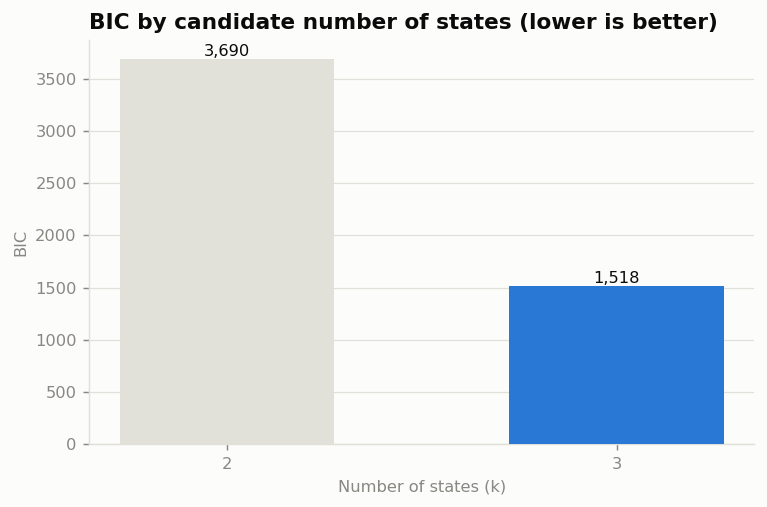

In [8]:
# --- NEW chart: BIC comparison bar chart ----------------------------------
ks = list(fitted.keys())
bics = [fitted[k][2] for k in ks]
colors_bic = [COLOR_PRICE if k == chosen_k else COLOR_GRID for k in ks]

fig, ax = plt.subplots(figsize=(6, 4), dpi=130)
bars = ax.bar([str(k) for k in ks], bics, color=colors_bic, width=0.55, zorder=3)
for rect, b in zip(bars, bics):
    ax.text(rect.get_x() + rect.get_width() / 2, b, f"{b:,.0f}",
            ha="center", va="bottom", fontsize=9, color=COLOR_INK)
ax.set_title("BIC by candidate number of states (lower is better)",
             color=COLOR_INK, fontsize=12, fontweight="bold", loc="left")
ax.set_xlabel("Number of states (k)", color=COLOR_AXIS, fontsize=9)
ax.set_ylabel("BIC", color=COLOR_AXIS, fontsize=9)
ax.tick_params(colors=COLOR_AXIS, labelsize=9)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(COLOR_GRID)
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.7, zorder=0)
fig.tight_layout()
plt.show()

## 5. Relabeling degli stati, decoding (Viterbi), filtro di persistenza

`hmmlearn` assegna gli indici di stato in modo arbitrario (lo stato 0 non è
necessariamente "il più calmo"). Riordiniamo quindi gli stati per livello
di stress medio: stato 0 = Normale, ultimo stato = Shock.

Il **decoding** usa l'algoritmo di **Viterbi full-sample**: trova la
sequenza di stati più probabile data *tutta* la serie storica. È corretto
per una classificazione retrospettiva e descrittiva ("quando c'è stato
stress di liquidità, storicamente") — **non** è un segnale di trading live
(per quello servirebbe un filtraggio solo-forward).

Infine, un **filtro di isteresi** (`MIN_DURATION`) unisce ogni run di
regime più corto della soglia al run adiacente più lungo: serve a evitare
che singoli giorni anomali producano "flicker" isolati di 1-3 giorni,
quando l'obiettivo è leggere il regime come una fase persistente (settimane
di stress), non un'etichetta che cambia tick per tick.

In [9]:
def relabel_states_by_stress(model, X: np.ndarray) -> dict:
    """Order state indices by mean standardized feature value ascending:
    state 0 = lowest stress = Normal, last state = highest stress = Shock."""
    stress_score = model.means_.mean(axis=1)
    order = np.argsort(stress_score)
    return {old: new for new, old in enumerate(order)}


def decode_regimes(model, X: np.ndarray, remap: dict) -> np.ndarray:
    """Full-sample Viterbi decoding (retrospective, not a live signal)."""
    raw_states = model.predict(X)
    return np.array([remap[s] for s in raw_states])


def apply_min_duration_filter(states: pd.Series, min_duration: int = 5) -> pd.Series:
    """Hysteresis filter: merges any contiguous regime run shorter than
    min_duration days into whichever neighboring run is longer. Does NOT
    refit the HMM - it is a smoothing step on top of the Viterbi path."""
    s = states.copy()
    while True:
        groups = (s != s.shift()).cumsum()
        run_lengths = s.groupby(groups).transform("size")
        if not (run_lengths < min_duration).any():
            break
        short_group_id = groups[run_lengths < min_duration].iloc[0]
        seg_index = groups[groups == short_group_id].index
        start_pos = s.index.get_loc(seg_index[0])
        end_pos = s.index.get_loc(seg_index[-1])

        prev_state = s.iloc[start_pos - 1] if start_pos > 0 else None
        next_state = s.iloc[end_pos + 1] if end_pos < len(s) - 1 else None

        if prev_state is None and next_state is None:
            break
        elif prev_state is None:
            new_state = next_state
        elif next_state is None:
            new_state = prev_state
        else:
            prev_run_len = (groups == groups.iloc[start_pos - 1]).sum()
            next_run_len = (groups == groups.iloc[end_pos + 1]).sum()
            new_state = prev_state if prev_run_len >= next_run_len else next_state

        s.iloc[start_pos:end_pos + 1] = new_state
    return s


def compute_state_probabilities(model, X: np.ndarray, remap: dict) -> np.ndarray:
    """Smoothed posterior state probabilities (forward-backward), columns
    reordered to match the stress-ordered state labels."""
    raw_probs = model.predict_proba(X)
    probs = np.zeros_like(raw_probs)
    for old, new in remap.items():
        probs[:, new] = raw_probs[:, old]
    return probs


remap = relabel_states_by_stress(model, X)
states_raw = pd.Series(decode_regimes(model, X, remap), index=feat.index, name="regime")

states = states_raw
if MIN_DURATION > 1:
    states = apply_min_duration_filter(states_raw, MIN_DURATION)
    n_changed = (states_raw != states).sum()
    print(f"Min-duration filter (>= {MIN_DURATION} days): reassigned {n_changed} days "
          f"({n_changed / len(states) * 100:.1f}% of sample).")

probs = compute_state_probabilities(model, X, remap)
labels = regime_labels(chosen_k)
print("\nRegime labels:", dict(enumerate(labels)))

if true_state is not None:
    aligned_truth = true_state.loc[states.index]
    # only compares against the nearest demo state if chosen_k != 2 - the demo ground truth is binary
    if chosen_k == 2:
        agreement = (aligned_truth.values == states.values).mean()
        agreement = max(agreement, 1 - agreement)
        print(f"\n[demo check] Agreement with the TRUE simulated regime: {agreement * 100:.1f}%")

Min-duration filter (>= 5 days): reassigned 12 days (0.5% of sample).

Regime labels: {0: 'Normal', 1: 'Elevated (1)', 2: 'Shock'}


### Grafico aggiuntivo — matrice di transizione

La matrice di transizione stimata dall'HMM mostra, per ogni riga (stato di
partenza), la probabilità di rimanere nello stesso regime o di passare a un
altro il giorno successivo. La diagonale alta conferma che i regimi sono
**persistenti** (fasi che durano giorni/settimane), non rumore
giorno-per-giorno.

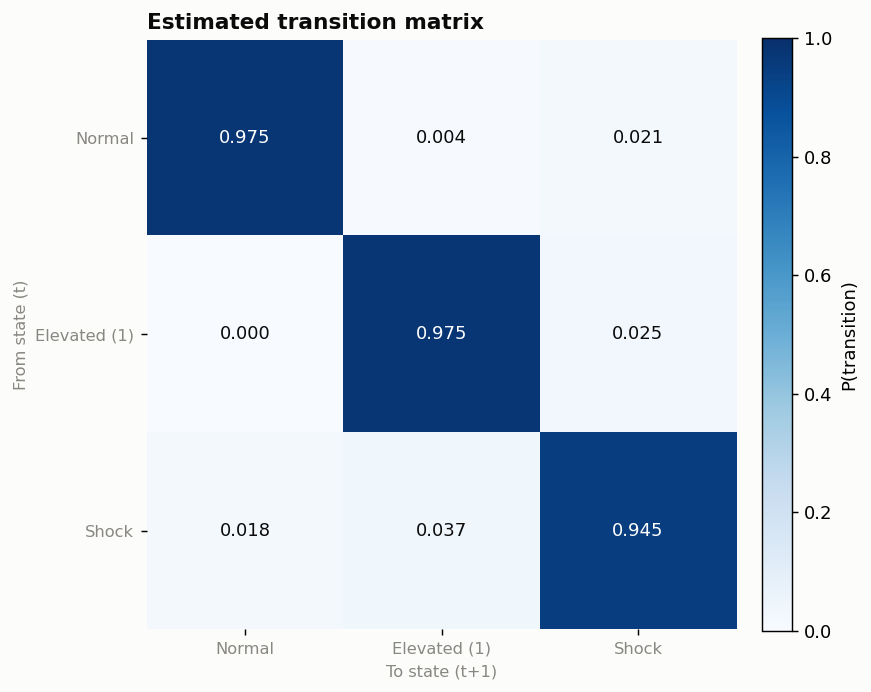


Expected regime persistence (avg. consecutive days) from the transition matrix diagonal:
  Normal: 1 / (1 - P_ii) = 40.0 days
  Elevated (1): 1 / (1 - P_ii) = 40.3 days
  Shock: 1 / (1 - P_ii) = 18.3 days


In [10]:
# --- NEW chart: transition matrix heatmap ---------------------------------
# Reorder the raw transition matrix rows/cols to match the stress-ordered labels
order = [old for old, new in sorted(remap.items(), key=lambda kv: kv[1])]
P = model.transmat_[np.ix_(order, order)]

fig, ax = plt.subplots(figsize=(1.6 * chosen_k + 2, 1.6 * chosen_k + 1.5), dpi=130)
im = ax.imshow(P, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(chosen_k)); ax.set_xticklabels(labels, fontsize=9, color=COLOR_AXIS)
ax.set_yticks(range(chosen_k)); ax.set_yticklabels(labels, fontsize=9, color=COLOR_AXIS)
ax.set_xlabel("To state (t+1)", color=COLOR_AXIS, fontsize=9)
ax.set_ylabel("From state (t)", color=COLOR_AXIS, fontsize=9)
ax.set_title("Estimated transition matrix", color=COLOR_INK, fontsize=12, fontweight="bold", loc="left")
for i in range(chosen_k):
    for j in range(chosen_k):
        txt_color = "white" if P[i, j] > 0.5 else COLOR_INK
        ax.text(j, i, f"{P[i, j]:.3f}", ha="center", va="center", fontsize=10, color=txt_color)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="P(transition)")
fig.tight_layout()
plt.show()

print("\nExpected regime persistence (avg. consecutive days) from the transition matrix diagonal:")
for i, lab in enumerate(labels):
    print(f"  {lab}: 1 / (1 - P_ii) = {1 / (1 - P[i, i]):.1f} days")

## 6. Statistiche di sintesi per regime

Quanto tempo l'ETF ha trascorso in ciascun regime, quanto durano in media
gli episodi, e come si comportano le feature (in z-score) all'interno di
ciascun regime — utile direttamente per la relazione/slide del progetto.

In [11]:
def summarize_regimes(states: pd.Series, feat: pd.DataFrame, labels: list[str]) -> pd.DataFrame:
    n = len(states)
    groups = (states != states.shift()).cumsum()
    durations = states.groupby(groups).agg(["first", "size"])
    feat_aligned = feat.loc[states.index]

    rows = []
    for k in sorted(states.unique()):
        mask = states == k
        avg_dur = durations.loc[durations["first"] == k, "size"].mean()
        means = feat_aligned[mask].mean()
        row = {
            "regime": labels[k],
            "% of days": mask.mean() * 100,
            "n days": mask.sum(),
            "avg persistence (days)": avg_dur,
        }
        row.update({f"mean {c} (z)": v for c, v in means.items()})
        rows.append(row)
    return pd.DataFrame(rows).set_index("regime")


summary_table = summarize_regimes(states, feat, labels)
summary_table

,% of days,n days,avg persistence (days),mean park_vol (z),mean amihud (z),mean prem_disc (z)
regime,,,,,,
Normal,20.2771,483,40.2500,-0.7276,-0.5814,-0.6800
Elevated (1),48.7825,1162,48.4167,-0.4146,-0.3764,-0.3925
Shock,30.9404,737,21.6765,1.4160,1.1044,1.3384


## 7. Grafici principali — prezzo con regimi evidenziati

Due grafici diagnostici, entrambi salvati su file **e** mostrati a schermo:

1. Prezzo dell'ETF con le fasi di stress/elevato evidenziate sullo sfondo
   (intensità = severità, stessa tinta blu/arancio della palette).
2. Versione dettagliata a due pannelli: sopra, ogni giorno colorato per
   regime decodificato (Viterbi, scala sequenziale ordinale); sotto, le
   probabilità *smussate* (forward-backward) di ciascun regime — mostra
   quanto è "sicuro" il modello giorno per giorno, non solo l'etichetta dura.

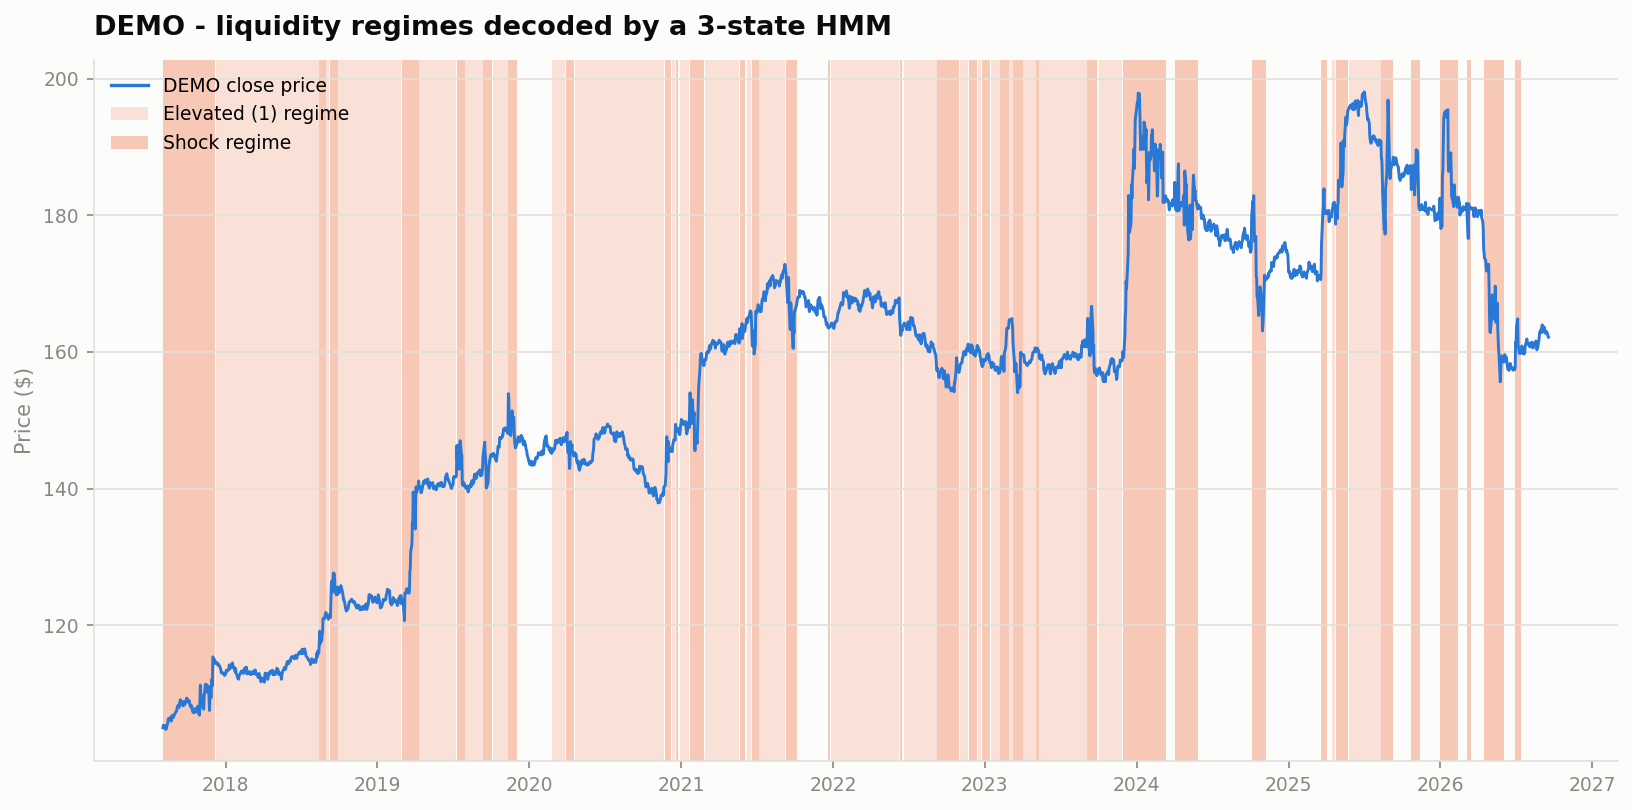

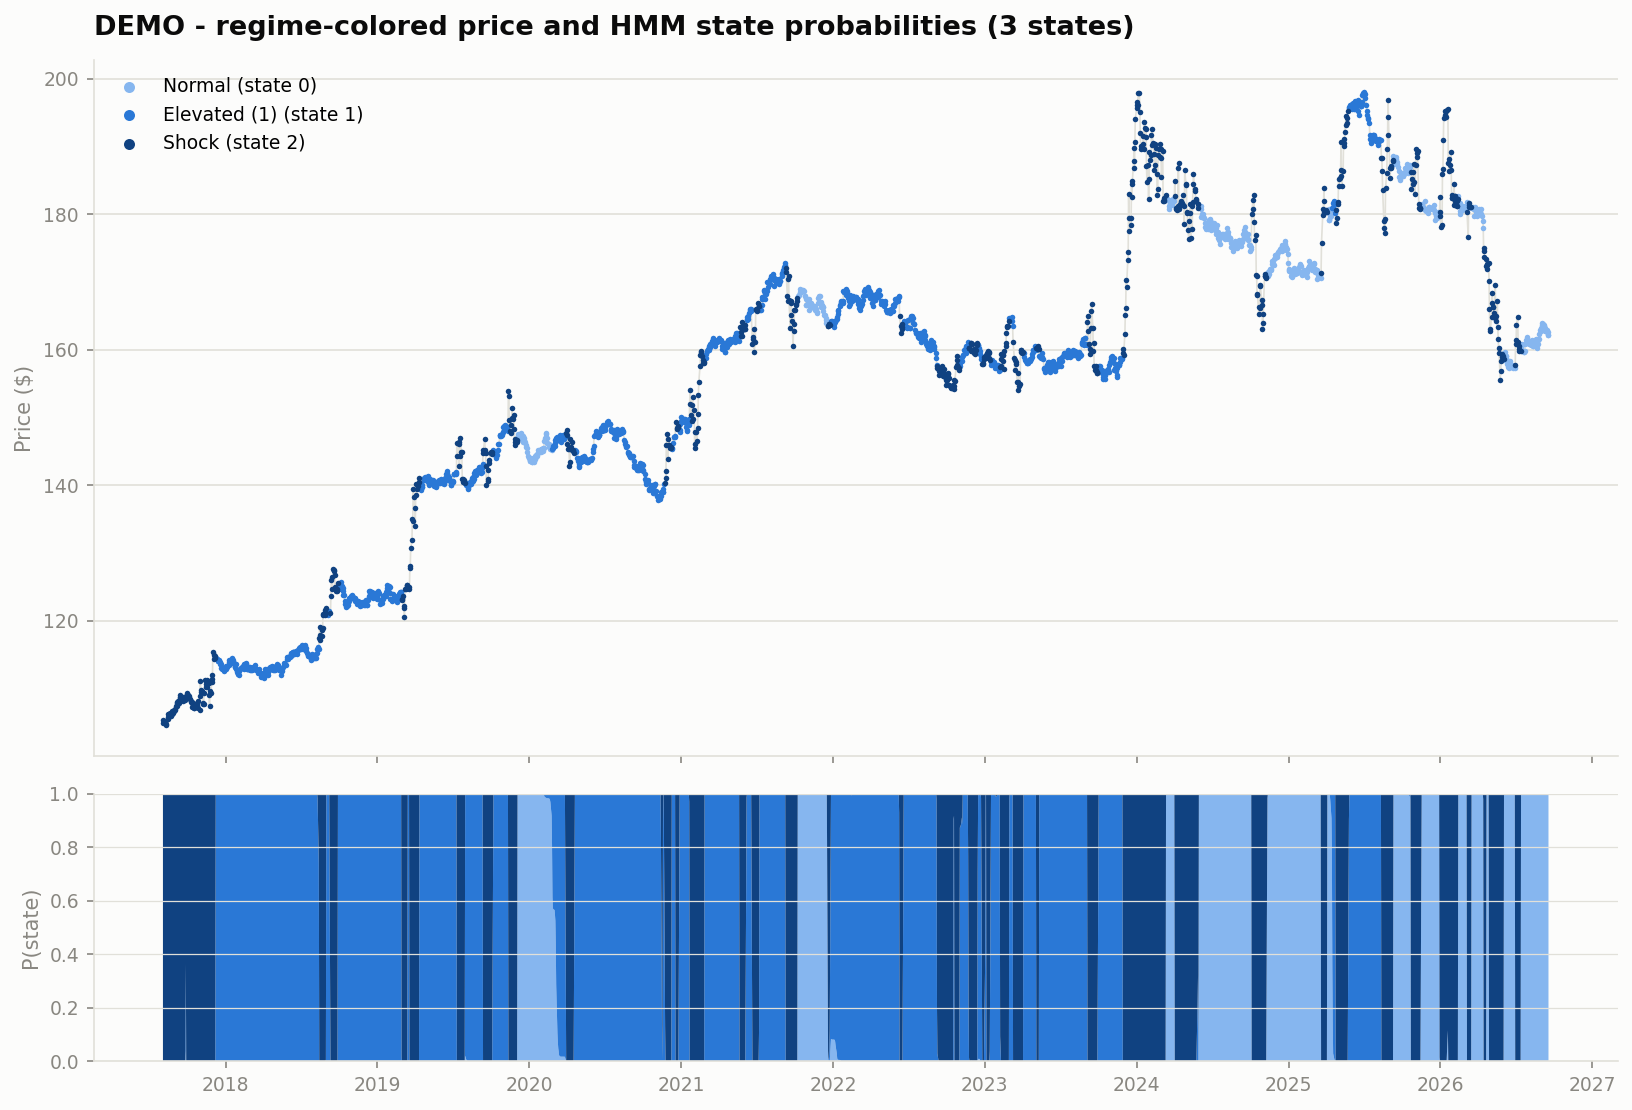

Charts saved to ./demo_liquidity_regimes.png and ./demo_liquidity_regimes_detailed.png


In [12]:
def plot_regimes(price: pd.Series, states: pd.Series, ticker: str, out_path: str,
                  n_states: int, labels: list[str]):
    fig, ax = plt.subplots(figsize=(11, 5.5), dpi=150)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)

    max_state = n_states - 1
    alpha_max = 0.35
    groups = (states != states.shift()).cumsum()
    for _, seg in states.groupby(groups):
        s = seg.iloc[0]
        if s > 0:
            alpha = alpha_max * (s / max_state)
            ax.axvspan(seg.index[0], seg.index[-1], color=COLOR_SHOCK, alpha=alpha, lw=0)

    ax.plot(price.index, price.values, color=COLOR_PRICE, linewidth=1.4, zorder=3)
    ax.set_title(f"{ticker} - liquidity regimes decoded by a {n_states}-state HMM",
                 color=COLOR_INK, fontsize=13, fontweight="bold", pad=12, loc="left")
    ax.set_ylabel("Price ($)", color=COLOR_AXIS, fontsize=10)
    ax.tick_params(colors=COLOR_AXIS, labelsize=9)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(COLOR_GRID)
    ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)

    legend_handles = [plt.Line2D([0], [0], color=COLOR_PRICE, lw=1.6, label=f"{ticker} close price")]
    for s in range(1, n_states):
        alpha = alpha_max * (s / max_state)
        legend_handles.append(Patch(facecolor=COLOR_SHOCK, alpha=alpha, label=f"{labels[s]} regime"))
    ax.legend(handles=legend_handles, loc="upper left", frameon=False, fontsize=9)

    fig.tight_layout()
    fig.savefig(out_path, facecolor=SURFACE)
    return fig


def plot_regimes_detailed(price: pd.Series, states: pd.Series, probs: np.ndarray,
                           ticker: str, out_path: str, n_states: int, labels: list[str]):
    colors = ramp_colors(n_states)

    fig, (ax_price, ax_prob) = plt.subplots(
        2, 1, figsize=(11, 7.5), dpi=150, sharex=True,
        gridspec_kw={"height_ratios": [2.6, 1]},
    )
    fig.patch.set_facecolor(SURFACE)

    ax_price.set_facecolor(SURFACE)
    ax_price.plot(price.index, price.values, color=COLOR_GRID, linewidth=0.8, zorder=1)
    for k in range(n_states):
        mask = states.values == k
        ax_price.scatter(price.index[mask], price.values[mask],
                          color=colors[k], s=7, linewidths=0, zorder=2, label=f"{labels[k]} (state {k})")
    ax_price.set_title(f"{ticker} - regime-colored price and HMM state probabilities ({n_states} states)",
                        color=COLOR_INK, fontsize=13, fontweight="bold", pad=12, loc="left")
    ax_price.set_ylabel("Price ($)", color=COLOR_AXIS, fontsize=10)
    ax_price.tick_params(colors=COLOR_AXIS, labelsize=9)
    for spine in ["top", "right"]:
        ax_price.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax_price.spines[spine].set_color(COLOR_GRID)
    ax_price.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)
    ax_price.legend(loc="upper left", frameon=False, fontsize=9, markerscale=2)

    ax_prob.set_facecolor(SURFACE)
    ax_prob.stackplot(price.index, probs.T, colors=colors, linewidth=0,
                       labels=[f"{lab} (state {k})" for k, lab in enumerate(labels)])
    ax_prob.set_ylabel("P(state)", color=COLOR_AXIS, fontsize=10)
    ax_prob.set_ylim(0, 1)
    ax_prob.tick_params(colors=COLOR_AXIS, labelsize=9)
    for spine in ["top", "right"]:
        ax_prob.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax_prob.spines[spine].set_color(COLOR_GRID)
    ax_prob.grid(axis="y", color=COLOR_GRID, linewidth=0.6, zorder=0)

    fig.tight_layout()
    fig.savefig(out_path, facecolor=SURFACE)
    return fig


price_aligned = df["Close"].loc[states.index]

fig1 = plot_regimes(price_aligned, states, ticker_label,
                     f"{OUT_DIR}/{ticker_label.lower()}_liquidity_regimes.png",
                     n_states=chosen_k, labels=labels)
plt.show()

fig2 = plot_regimes_detailed(price_aligned, states, probs, ticker_label,
                              f"{OUT_DIR}/{ticker_label.lower()}_liquidity_regimes_detailed.png",
                              n_states=chosen_k, labels=labels)
plt.show()

print(f"Charts saved to {OUT_DIR}/{ticker_label.lower()}_liquidity_regimes.png "
      f"and {OUT_DIR}/{ticker_label.lower()}_liquidity_regimes_detailed.png")

## 8. Ulteriori grafici di analisi

### 8.1 Distribuzione delle feature per regime

Boxplot delle feature standardizzate, raggruppate per regime decodificato:
mostra visivamente **quanto bene ciascuna feature separa i regimi** — è lo
stesso tipo di controllo empirico usato per decidere di scartare `vol_z`
(poca separazione tra i gruppi) e tenere `park_vol`/`amihud`/`prem_disc`.

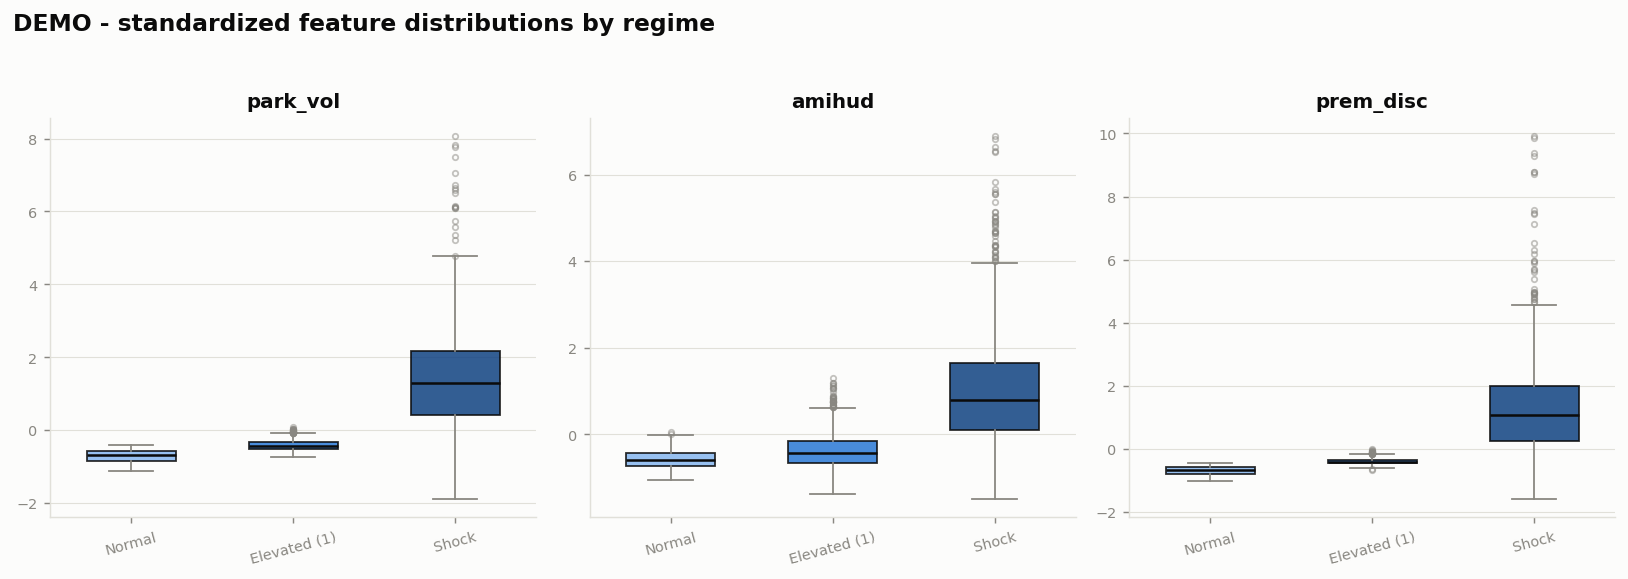

In [13]:
# --- NEW chart: feature distributions by regime (boxplots, small multiples) ---
feat_aligned = feat.loc[states.index]
colors = ramp_colors(chosen_k)

fig, axes = plt.subplots(1, len(feat.columns), figsize=(4.2 * len(feat.columns), 4.5), dpi=130)
if len(feat.columns) == 1:
    axes = [axes]
for ax, col in zip(axes, feat.columns):
    data_by_regime = [feat_aligned.loc[states == k, col].values for k in range(chosen_k)]
    bp = ax.boxplot(data_by_regime, patch_artist=True, widths=0.55,
                     medianprops=dict(color=COLOR_INK, linewidth=1.4),
                     whiskerprops=dict(color=COLOR_AXIS), capprops=dict(color=COLOR_AXIS),
                     flierprops=dict(markeredgecolor=COLOR_AXIS, markersize=3, alpha=0.5))
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.85)
        patch.set_edgecolor(COLOR_INK)
    ax.set_xticks(range(1, chosen_k + 1))
    ax.set_xticklabels(labels, fontsize=8, color=COLOR_AXIS, rotation=15)
    ax.set_title(col, color=COLOR_INK, fontsize=11, fontweight="bold")
    ax.tick_params(colors=COLOR_AXIS, labelsize=8)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(COLOR_GRID)
    ax.grid(axis="y", color=COLOR_GRID, linewidth=0.6, zorder=0)
fig.suptitle(f"{ticker_label} - standardized feature distributions by regime",
             color=COLOR_INK, fontsize=13, fontweight="bold", x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 8.2 Distribuzione della durata dei regimi

Istogramma della lunghezza (in giorni) di ciascun episodio di regime:
conferma visivamente che, dopo il filtro di isteresi, i regimi si
comportano come **fasi persistenti** e non come rumore ad alta frequenza.

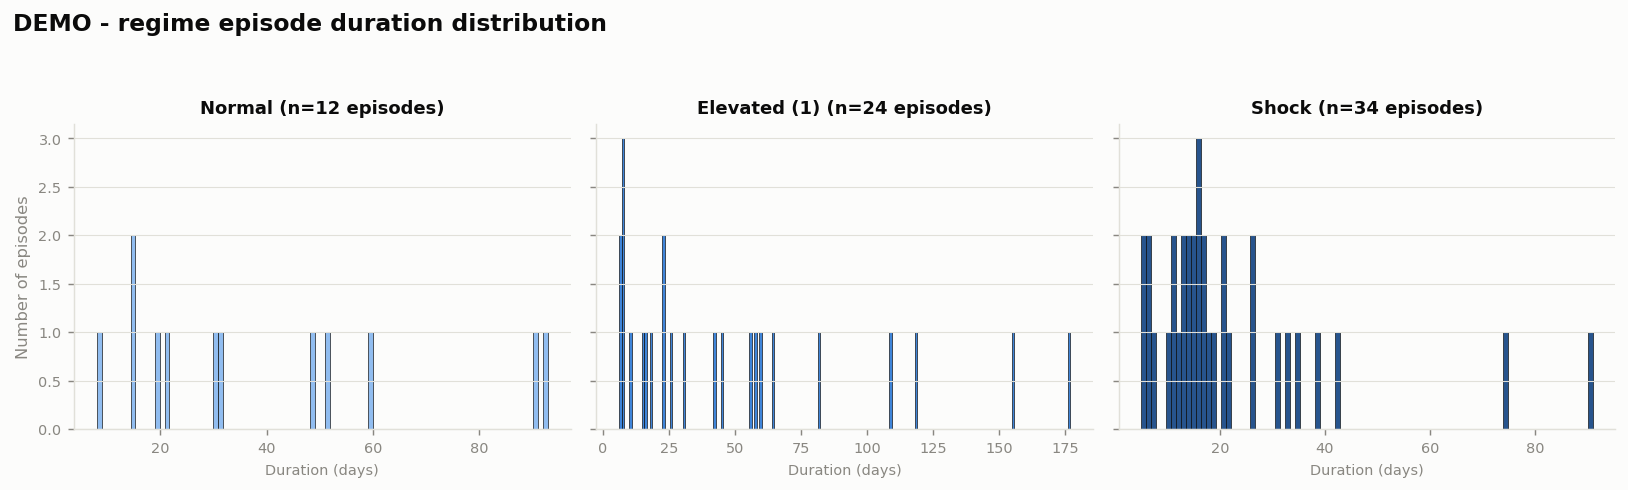

In [14]:
# --- NEW chart: regime duration histogram (small multiples per regime) ---
groups = (states != states.shift()).cumsum()
run_table = states.groupby(groups).agg(["first", "size"])
run_table.columns = ["regime", "duration"]

fig, axes = plt.subplots(1, chosen_k, figsize=(4.2 * chosen_k, 3.8), dpi=130, sharey=True)
if chosen_k == 1:
    axes = [axes]
for k, ax in enumerate(axes):
    durs = run_table.loc[run_table["regime"] == k, "duration"]
    ax.hist(durs, bins=max(5, int(durs.max()) if len(durs) else 5),
            color=colors[k], edgecolor=COLOR_INK, linewidth=0.4, alpha=0.9)
    ax.set_title(f"{labels[k]} (n={len(durs)} episodes)", color=COLOR_INK, fontsize=10, fontweight="bold")
    ax.set_xlabel("Duration (days)", color=COLOR_AXIS, fontsize=8)
    ax.tick_params(colors=COLOR_AXIS, labelsize=8)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(COLOR_GRID)
    ax.grid(axis="y", color=COLOR_GRID, linewidth=0.6, zorder=0)
axes[0].set_ylabel("Number of episodes", color=COLOR_AXIS, fontsize=9)
fig.suptitle(f"{ticker_label} - regime episode duration distribution",
             color=COLOR_INK, fontsize=13, fontweight="bold", x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 9. Confronto con eventi di stress storici noti

Come controllo *fuori campione* — l'HMM non vede mai questo calendario, è
usato solo a posteriori — confrontiamo i regimi decodificati con un elenco
curato di episodi di stress di mercato/liquidità obbligazionaria noti,
2015-2025. La domanda è semplice: **il modello etichetta questi episodi
noti come Elevated/Shock?** Se sì, è evidenza che i regimi decodificati
catturano fenomeni economicamente reali e non solo rumore statistico.

Fonti usate per compilare le date (settembre 2026):

- [September 2019 events in the U.S. repo market — Wikipedia](https://en.wikipedia.org/wiki/September_2019_events_in_the_U.S._repo_market)
- [Secondary Market Corporate Credit Facility — Federal Reserve Bank of New York](https://www.newyorkfed.org/markets/secondary-market-corporate-credit-facility)
- [Collapse of Silicon Valley Bank — Wikipedia](https://en.wikipedia.org/wiki/Collapse_of_Silicon_Valley_Bank)
- [Timeline: How US gov't scrambled as Silicon Valley Bank collapsed — Al Jazeera](https://www.aljazeera.com/economy/2023/3/15/timeline-how-us-govt-scrambled-as-silicon-valley-bank-collapsed)
- [Carry trades: A major unwinding is underway amid a stock sell-off — CNBC](https://www.cnbc.com/2024/08/05/carry-trades-a-major-unwinding-is-underway-amid-a-stock-sell-off.html)
- [U.S. Treasury yields: tariffs-led sell-off continues — CNBC](https://www.cnbc.com/2025/04/11/us-treasury-yields-investors-weigh-state-of-the-us-economy-.html)
- [Sell America — Wikipedia](https://en.wikipedia.org/wiki/Sell_America)
- [An anatomy of the 2022 gilt market crisis — Bank of England working paper](https://www.bankofengland.co.uk/-/media/boe/files/working-paper/2023/an-anatomy-of-the-2022-gilt-market-crisis.pdf)

**Nota:** questo confronto è significativo solo con dati reali
(`DEMO = False`). In modalità `DEMO` il percorso di prezzo è sintetico e
indipendente dagli eventi reali, quindi qualunque "hit rate" ottenuto in
quella modalità è privo di significato — il notebook lo segnala
esplicitamente a schermo.

In [15]:
def known_stress_events() -> pd.DataFrame:
    """Curated calendar of known fixed-income / bond-ETF liquidity stress
    episodes (2015-2025), compiled from Fed/BoE/press sources (see the
    markdown cell above for citations). Used purely as an OUT-OF-SAMPLE
    sanity check for the HMM-decoded regimes - the model never sees this
    calendar during fitting."""
    events = [
        ("2015-08-24", "Black Monday 2015", "China devaluation spillover, global equity flash crash"),
        ("2018-02-05", "Volmageddon", "XIV/short-vol ETN collapse, equity vol spike"),
        ("2018-12-24", "Q4 2018 selloff trough", "Fed hike fears, credit spread widening, equity trough"),
        ("2019-09-17", "Repo market crisis", "Overnight repo rate spikes to ~10%, Fed injects liquidity"),
        ("2020-03-23", "COVID-19 crash / Fed SMCCF", "Equity/credit market trough; Fed announces corporate credit facilities"),
        ("2022-09-23", "UK mini-budget / Gilt crisis start", "LDI-driven gilt market dislocation begins"),
        ("2022-09-28", "BoE emergency gilt intervention", "Bank of England announces emergency gilt purchases"),
        ("2023-03-10", "Silicon Valley Bank collapse", "SVB failure, US regional banking stress begins"),
        ("2023-03-19", "UBS-Credit Suisse rescue", "UBS agrees to acquire Credit Suisse in emergency deal"),
        ("2024-08-05", "Yen carry trade unwind", "BoJ hike triggers global carry-trade unwind, equity selloff"),
        ("2025-04-02", "'Liberation Day' tariffs announced", "Broad US tariff announcement triggers global market selloff"),
        ("2025-04-09", "Tariff-driven Treasury selloff peak", "'Sell America' trade; sharp Treasury yield spike, tariff pause announced"),
    ]
    out = pd.DataFrame(events, columns=["date", "event", "description"])
    out["date"] = pd.to_datetime(out["date"])
    return out.set_index("date")


EVENT_WINDOW = 5  # trading days around each event date to check for a regime hit

if DEMO:
    print("NOTE: DEMO mode - the price path is synthetic and unrelated to real market "
          "events, so this comparison is NOT meaningful. Shown for illustration of the "
          "mechanics only; re-run with DEMO = False for the real check.\n")

events_df = known_stress_events()
rows = []
for event_date, row in events_df.iterrows():
    in_sample = states.index.min() <= event_date <= states.index.max()
    if not in_sample:
        rows.append({"event": row["event"], "description": row["description"], "date": event_date,
                      "in_sample": False, "nearest_trading_day": None,
                      "regime_on_date": None, "max_regime_in_window": None, "flagged": None})
        continue

    pos = min(states.index.searchsorted(event_date), len(states) - 1)
    nearest_date = states.index[pos]
    regime_on_date = states.iloc[pos]

    lo, hi = max(0, pos - EVENT_WINDOW), min(len(states), pos + EVENT_WINDOW + 1)
    max_regime = states.iloc[lo:hi].max()

    rows.append({
        "event": row["event"], "description": row["description"], "date": event_date,
        "in_sample": True, "nearest_trading_day": nearest_date,
        "regime_on_date": labels[regime_on_date],
        "max_regime_in_window": labels[max_regime],
        "flagged": bool(max_regime > 0),
    })

events_result = pd.DataFrame(rows).set_index("date")
in_sample_events = events_result[events_result["in_sample"] == True]  # noqa: E712

if len(in_sample_events):
    hit_rate = in_sample_events["flagged"].mean() * 100
    print(f"Known stress events within the sample date range: {len(in_sample_events)} / {len(events_result)}")
    print(f"Share flagged Elevated/Shock within +/-{EVENT_WINDOW} trading days: {hit_rate:.1f}%")
else:
    print("No known stress events fall within this sample's date range "
          "(expected in DEMO mode, or if START is set later than 2015).")

events_result[["event", "description", "in_sample", "nearest_trading_day",
               "regime_on_date", "max_regime_in_window", "flagged"]]

NOTE: DEMO mode - the price path is synthetic and unrelated to real market events, so this comparison is NOT meaningful. Shown for illustration of the mechanics only; re-run with DEMO = False for the real check.

Known stress events within the sample date range: 11 / 12
Share flagged Elevated/Shock within +/-5 trading days: 90.9%


,event,description,in_sample,nearest_trading_day,regime_on_date,max_regime_in_window,flagged
date,,,,,,,
2015-08-24,Black Monday 2015,"China devaluation spillover, global equity fla...",False,NaT,NaN,NaN,None
2018-02-05,Volmageddon,"XIV/short-vol ETN collapse, equity vol spike",True,2018-02-05,Elevated (1),Elevated (1),True
2018-12-24,Q4 2018 selloff trough,"Fed hike fears, credit spread widening, equity...",True,2018-12-24,Elevated (1),Elevated (1),True
2019-09-17,Repo market crisis,"Overnight repo rate spikes to ~10%, Fed inject...",True,2019-09-17,Shock,Shock,True
2020-03-23,COVID-19 crash / Fed SMCCF,Equity/credit market trough; Fed announces cor...,True,2020-03-23,Elevated (1),Shock,True
2022-09-23,UK mini-budget / Gilt crisis start,LDI-driven gilt market dislocation begins,True,2022-09-23,Shock,Shock,True
2022-09-28,BoE emergency gilt intervention,Bank of England announces emergency gilt purch...,True,2022-09-28,Shock,Shock,True
2023-03-10,Silicon Valley Bank collapse,"SVB failure, US regional banking stress begins",True,2023-03-10,Shock,Shock,True
2023-03-19,UBS-Credit Suisse rescue,UBS agrees to acquire Credit Suisse in emergen...,True,2023-03-20,Shock,Shock,True


### Grafico aggiuntivo — eventi noti sovrapposti al prezzo con regimi

Stesso grafico prezzo/regime di prima, con una linea verticale tratteggiata
e un'etichetta per ciascun evento noto che ricade nell'intervallo
campionario: un controllo visivo immediato di quanto gli episodi Elevated/
Shock decodificati coincidano con la cronologia di stress di mercato nota.

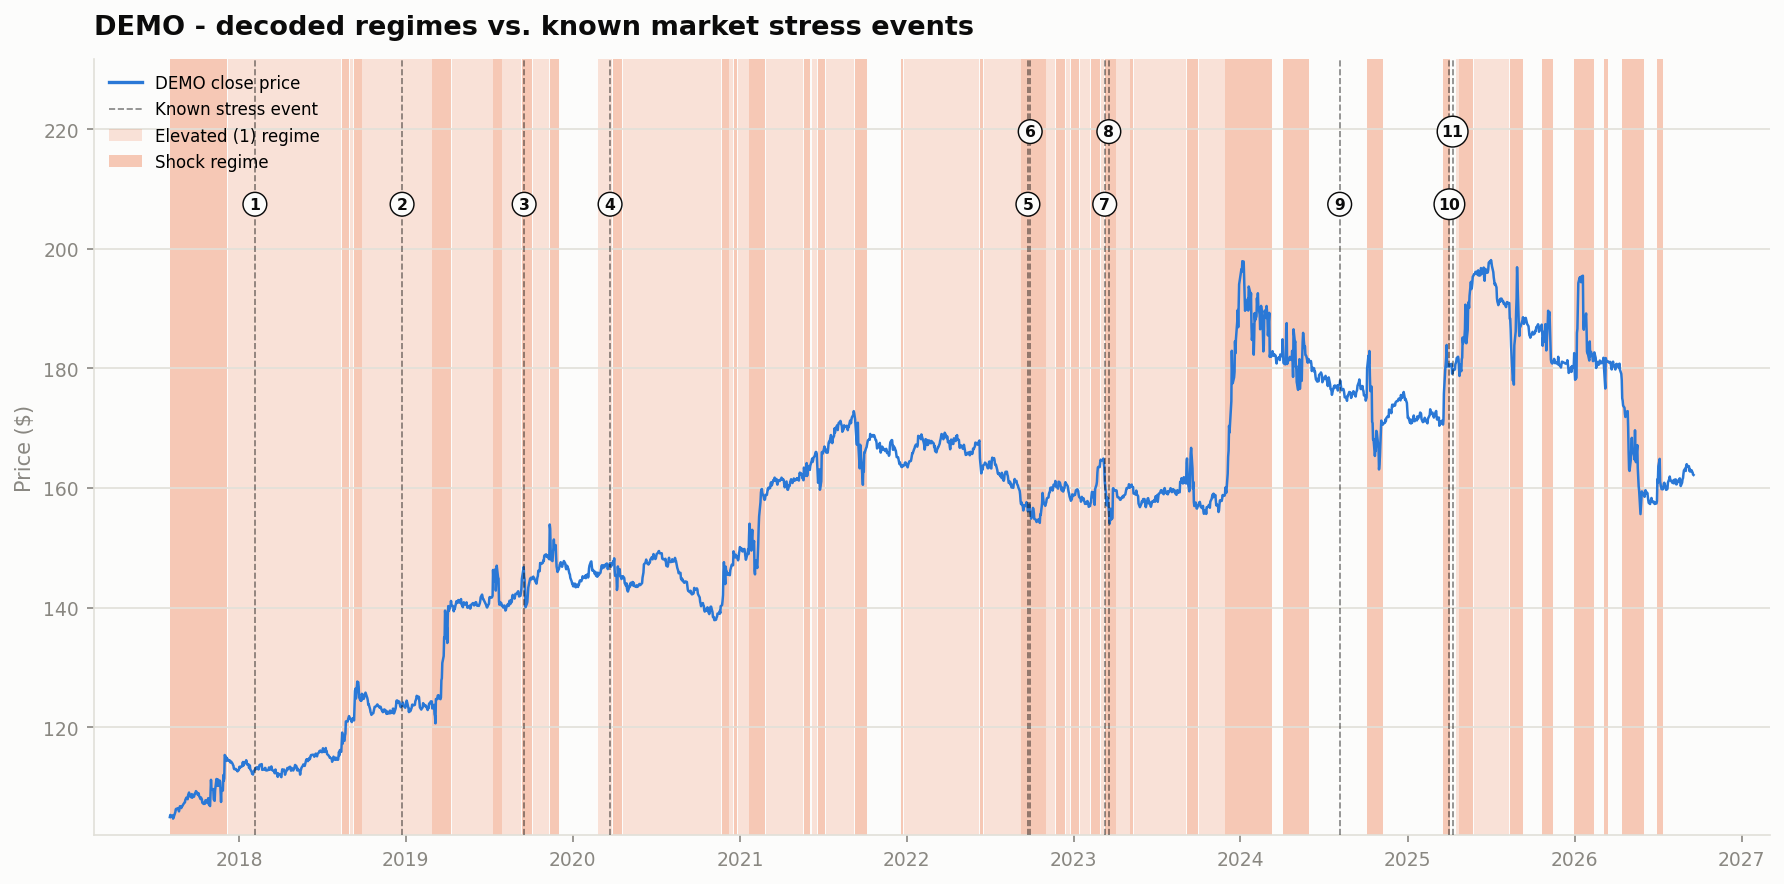

Event legend:
   1. 2018-02-05  Volmageddon                            -> Elevated/Shock
   2. 2018-12-24  Q4 2018 selloff trough                 -> Elevated/Shock
   3. 2019-09-17  Repo market crisis                     -> Elevated/Shock
   4. 2020-03-23  COVID-19 crash / Fed SMCCF             -> Elevated/Shock
   5. 2022-09-23  UK mini-budget / Gilt crisis start     -> Elevated/Shock
   6. 2022-09-28  BoE emergency gilt intervention        -> Elevated/Shock
   7. 2023-03-10  Silicon Valley Bank collapse           -> Elevated/Shock
   8. 2023-03-19  UBS-Credit Suisse rescue               -> Elevated/Shock
   9. 2024-08-05  Yen carry trade unwind                 -> NOT flagged
  10. 2025-04-02  'Liberation Day' tariffs announced     -> Elevated/Shock
  11. 2025-04-09  Tariff-driven Treasury selloff peak    -> Elevated/Shock


In [16]:
# --- NEW chart: known events overlaid on the regime-shaded price chart ---
# Events are numbered (not labeled with rotated text) because several known
# episodes sit only days apart (e.g. the UK gilt crisis start + BoE
# intervention, or SVB collapse + UBS-Credit Suisse rescue) - text labels at
# that spacing would overlap regardless of rotation. Numbers + a printed
# legend below keep the chart legible at any clustering density.
sorted_events = in_sample_events.sort_index()

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

max_state = chosen_k - 1
alpha_max = 0.35
groups = (states != states.shift()).cumsum()
for _, seg in states.groupby(groups):
    s = seg.iloc[0]
    if s > 0:
        alpha = alpha_max * (s / max_state)
        ax.axvspan(seg.index[0], seg.index[-1], color=COLOR_SHOCK, alpha=alpha, lw=0)

ax.plot(price_aligned.index, price_aligned.values, color=COLOR_PRICE, linewidth=1.2, zorder=3)

price_min, price_max = price_aligned.min(), price_aligned.max()
y_pad = (price_max - price_min) * 0.10
ax.set_ylim(price_min - (price_max - price_min) * 0.03, price_max + y_pad * 3.6)
y_lane0 = price_max + y_pad
y_lane1 = y_lane0 + y_pad * 1.3

# Some known events sit only days apart (e.g. SVB collapse + UBS-Credit Suisse
# rescue, or the tariff announcement + selloff peak) - at multi-year x-axis
# scale their markers would sit on top of each other. Alternate a close pair
# onto a second lane so both numbers stay readable.
date_span_days = (states.index.max() - states.index.min()).days
gap_threshold_days = max(date_span_days * 0.015, 10)

event_numbers = {}
prev_date, lane = None, 0
for i, (event_date, row) in enumerate(sorted_events.iterrows(), start=1):
    event_numbers[event_date] = i
    lane = 1 - lane if (prev_date is not None and (event_date - prev_date).days < gap_threshold_days) else 0
    y_marker = y_lane1 if lane else y_lane0
    ax.axvline(event_date, color=COLOR_INK, linestyle="--", linewidth=0.8, alpha=0.5, zorder=4)
    ax.annotate(str(i), xy=(event_date, y_marker), ha="center", va="center", fontsize=7.5,
                fontweight="bold", color=COLOR_INK, zorder=5,
                bbox=dict(boxstyle="circle,pad=0.28", facecolor=SURFACE, edgecolor=COLOR_INK, linewidth=0.7))
    prev_date = event_date

ax.set_title(f"{ticker_label} - decoded regimes vs. known market stress events",
             color=COLOR_INK, fontsize=13, fontweight="bold", pad=12, loc="left")
ax.set_ylabel("Price ($)", color=COLOR_AXIS, fontsize=10)
ax.tick_params(colors=COLOR_AXIS, labelsize=9)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(COLOR_GRID)
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)

legend_handles = [plt.Line2D([0], [0], color=COLOR_PRICE, lw=1.6, label=f"{ticker_label} close price"),
                  plt.Line2D([0], [0], color=COLOR_INK, lw=0.8, linestyle="--", alpha=0.5, label="Known stress event")]
for s in range(1, chosen_k):
    alpha = alpha_max * (s / max_state)
    legend_handles.append(Patch(facecolor=COLOR_SHOCK, alpha=alpha, label=f"{labels[s]} regime"))
ax.legend(handles=legend_handles, loc="upper left", frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/{ticker_label.lower()}_regimes_vs_events.png", facecolor=SURFACE)
plt.show()

print("Event legend:")
for event_date, row in sorted_events.iterrows():
    event_name = row["event"]
    flag = "Elevated/Shock" if row["flagged"] else "NOT flagged"
    print(f"  {event_numbers[event_date]:>2}. {event_date.date()}  {event_name:<38} -> {flag}")

## 10. Confronto cross-ETF: LQD vs un secondo segmento di credito (es. HYG)

Investment grade (LQD) e high yield (HYG) sono due segmenti dello stesso
mercato del credito corporate, ma con rischio di credito molto diverso:
high yield è più vicino, per sensibilità, al mercato azionario (spread più
ampi, rating sub-investment-grade, base di investitori diversa). Una
domanda naturale è se lo **stress di liquidità** decodificato dall'HMM sia:

- **contemporaneo** tra i due segmenti (la liquidità si inceppa insieme,
  segno di uno shock sistemico/di mercato che colpisce tutto il credito
  corporate contemporaneamente), oppure
- **sfasato nel tempo** (un segmento anticipa l'altro), il che
  suggerirebbe un canale di trasmissione specifico — ad esempio high yield,
  più sensibile al ciclo del credito e con una base di investitori più
  orientata al rischio, potrebbe entrare in stress prima di investment
  grade, oppure il contrario se lo shock parte da un canale legato ai
  tassi (che colpisce prima l'investment grade, più duration-sensitive).

Questa sezione ripete l'intera pipeline (feature engineering, selezione
BIC, fit HMM, decoding, filtro di isteresi) su un secondo ticker, poi
confronta i due regimi decodificati con una **cross-correlation function
(CCF)** su uno score di stress continuo, per stimare empiricamente se
esiste un lead/lag sistematico.

**Nota:** come per la Sezione 9, questo confronto è pienamente significativo
solo con dati reali (`DEMO = False`). In modalità `DEMO`, il notebook
costruisce comunque una seconda serie sintetica il cui regime "vero" è
**deliberatamente sfasato di un numero noto di giorni** rispetto al primo
(si veda `LEAD_DAYS` sotto): questo serve a validare che la metodologia di
stima del lead/lag (la CCF) recuperi correttamente lo sfasamento noto,
prima di applicarla ai dati reali.

In [17]:
# ============================================================================
# CONFIGURATION - second ticker for the cross-ETF comparison
# ============================================================================
SECOND_TICKER = "HYG"                              # iShares iBoxx $ High Yield Corporate Bond ETF
SECOND_NAV_CSV_PATH = "hyg_nav_history.csv"         # (Date, NAV) CSV, same format as LQD's
MAX_LAG_DAYS = 10                                   # +/- trading days searched by the cross-correlation
LEAD_DAYS = 3                                       # DEMO mode only: known synthetic lead of the 2nd series


def run_liquidity_pipeline(df2, nav2, ticker_label2, n_states_candidates, drop_features, min_duration, seed=0):
    """Runs the full pipeline (feature engineering -> BIC model comparison ->
    HMM fit -> relabeling -> Viterbi decoding -> hysteresis filter) on a
    SECOND ticker, reusing every atomic function already defined above for
    the main LQD analysis (Sections 3-5) - no logic is duplicated, only
    orchestrated again for a second (df, nav) pair."""
    prem_disc2 = premium_discount_feature(df2["Close"], nav2)
    feat2 = build_features(df2, extra_features={"prem_disc": prem_disc2})
    if drop_features:
        feat2 = feat2.drop(columns=[c for c in drop_features if c in feat2.columns])

    X2 = feat2.values
    fitted2 = {}
    for k in n_states_candidates:
        model_k, ll_k = fit_hmm(X2, n_states=k, n_init=10, seed=seed)
        fitted2[k] = (model_k, ll_k, bic_score(model_k, X2, k))
    chosen_k2 = min(fitted2, key=lambda k: fitted2[k][2]) if len(n_states_candidates) > 1 else n_states_candidates[0]
    model2, ll2, _ = fitted2[chosen_k2]

    remap2 = relabel_states_by_stress(model2, X2)
    states2 = pd.Series(decode_regimes(model2, X2, remap2), index=feat2.index, name="regime")
    if min_duration > 1:
        states2 = apply_min_duration_filter(states2, min_duration)
    probs2 = compute_state_probabilities(model2, X2, remap2)
    labels2 = regime_labels(chosen_k2)

    return {
        "ticker": ticker_label2, "feat": feat2, "states": states2, "probs": probs2,
        "model": model2, "chosen_k": chosen_k2, "labels": labels2,
        "price": df2["Close"].loc[states2.index], "fitted": fitted2,
    }


def generate_demo_data_shifted(true_state_arr, dates, seed):
    """Same generative model as generate_demo_data(), but driven by a GIVEN
    true_state path instead of simulating a fresh one - used to build a
    second synthetic series whose regime is a known, shifted copy of the
    first, so the lead/lag estimation below can be validated against a
    known ground truth."""
    rng = np.random.default_rng(seed)
    n_days = len(true_state_arr)
    mu = np.where(true_state_arr == 0, 0.0001, -0.0008)
    sigma = np.where(true_state_arr == 0, 0.0030, 0.0150)
    daily_ret = rng.normal(mu, sigma)
    close = 100 * np.cumprod(1 + daily_ret)
    open_ = np.empty(n_days)
    open_[0] = 100.0
    open_[1:] = close[:-1]
    range_pct = np.where(true_state_arr == 0, rng.uniform(0.001, 0.004, n_days),
                          rng.uniform(0.010, 0.035, n_days))
    high = np.maximum(open_, close) * (1 + range_pct / 2)
    low = np.minimum(open_, close) * (1 - range_pct / 2)
    base_vol = np.where(true_state_arr == 0, 6_000_000, 9_000_000)
    volume = rng.lognormal(mean=np.log(base_vol), sigma=np.where(true_state_arr == 0, 0.15, 0.55))
    df2 = pd.DataFrame({"Open": open_, "High": high, "Low": low, "Close": close, "Volume": volume}, index=dates)
    df2.index.name = "Date"
    noise = rng.normal(0, 0.0006, n_days)
    dislocation = np.where(true_state_arr == 1, rng.normal(0, 0.012, n_days), 0.0)
    nav2 = pd.Series(df2["Close"].values * (1 - noise - dislocation), index=dates, name="NAV")
    return df2, nav2


if DEMO:
    # Build the second series' TRUE state as the first series' true_state,
    # shifted LEAD_DAYS earlier: series_2[t] = true_state[t + LEAD_DAYS], i.e.
    # series 2 "previews" today what series 1 will show LEAD_DAYS from now -
    # series 2 LEADS series 1 by construction. shift(-k) brings future values
    # backward in pandas, which is exactly this operation.
    shifted_true_state = true_state.shift(-LEAD_DAYS).dropna().astype(int)
    df_2, nav_2 = generate_demo_data_shifted(shifted_true_state.values, shifted_true_state.index, seed=99)
    print(f"DEMO mode: built a second synthetic series ({SECOND_TICKER}) whose true regime "
          f"LEADS the first series' by {LEAD_DAYS} trading days (known ground truth).")
else:
    print(f"Downloading {SECOND_TICKER} from Yahoo Finance ({START} to {END or 'today'})...")
    df_2 = load_from_yfinance(SECOND_TICKER, START, END)
    nav_2 = load_nav_csv(SECOND_NAV_CSV_PATH)

result_2 = run_liquidity_pipeline(df_2, nav_2, SECOND_TICKER, N_STATES_CANDIDATES, DROP_FEATURES, MIN_DURATION)
print(f"{SECOND_TICKER}: {result_2['feat'].shape[0]} days x {result_2['feat'].shape[1]} features, "
      f"k={result_2['chosen_k']} states chosen, labels={dict(enumerate(result_2['labels']))}")

DEMO mode: built a second synthetic series (HYG) whose true regime LEADS the first series' by 3 trading days (known ground truth).


HYG: 2379 days x 3 features, k=3 states chosen, labels={0: 'Normal', 1: 'Elevated (1)', 2: 'Shock'}


### Score di stress continuo e cross-correlation function (CCF)

Per confrontare due HMM stimati indipendentemente (con stati e matrici di
transizione proprie) non ha senso correlare direttamente le etichette
discrete di regime: si costruisce invece uno **score di stress continuo**,
il valore atteso dello stato sotto le probabilità smussate
$\mathbb{E}[S_t]=\sum_k k\cdot P(S_t=k\mid \text{dati})$, che varia con
continuità tra $0$ (Normal) e $K-1$ (Shock) e riflette anche l'incertezza
del modello, non solo l'etichetta Viterbi.

La CCF è definita come $CCF(\ell) = \text{corr}(a_t,\, b_{t-\ell})$: un
lag $\ell^\star>0$ che massimizza la CCF significa che lo score di $b$ di
$\ell^\star$ giorni fa somiglia allo score di $a$ oggi, cioè **$b$
anticipa $a$** di $\ell^\star$ giorni; $\ell^\star<0$ significa il
contrario ($a$ anticipa $b$); $\ell^\star\approx0$ indica stress
contemporaneo.

In [18]:
def expected_regime_score(probs, n_states):
    """Continuous stress score: E[state_t] under the smoothed posterior,
    in [0, n_states-1]. Comparable across two independently-fitted HMMs
    (with possibly different k) in a way that discrete regime labels are not."""
    weights = np.arange(n_states)
    return (probs * weights).sum(axis=1)


def cross_correlation(a, b, max_lag=10):
    """CCF(lag) = corr(a_t, b_{t-lag}) for lag in [-max_lag, max_lag].
    lag > 0 maximizing the CCF means b leads a by `lag` days; lag < 0 means
    a leads b by |lag| days (see markdown above for the full derivation)."""
    lags = list(range(-max_lag, max_lag + 1))
    ccf = pd.Series([a.corr(b.shift(lag)) for lag in lags], index=lags, name="ccf")
    return ccf, ccf.idxmax()


score_a = pd.Series(expected_regime_score(probs, chosen_k), index=states.index, name=ticker_label)
score_b = pd.Series(expected_regime_score(result_2["probs"], result_2["chosen_k"]),
                     index=result_2["states"].index, name=SECOND_TICKER)

common_idx = score_a.index.intersection(score_b.index)
a, b = score_a.loc[common_idx], score_b.loc[common_idx]
print(f"Overlapping sample: {len(common_idx)} days ({common_idx.min().date()} to {common_idx.max().date()})")

contemporaneous_corr = a.corr(b)
ccf, best_lag = cross_correlation(a, b, max_lag=MAX_LAG_DAYS)

print(f"\nContemporaneous correlation ({ticker_label} vs {SECOND_TICKER} stress score): {contemporaneous_corr:.3f}")
print(f"Best lag (CCF peak): {best_lag:+d} trading days (CCF = {ccf.loc[best_lag]:.3f})")
if best_lag > 0:
    print(f"  -> {SECOND_TICKER} appears to LEAD {ticker_label} by {best_lag} day(s).")
elif best_lag < 0:
    print(f"  -> {ticker_label} appears to LEAD {SECOND_TICKER} by {-best_lag} day(s).")
else:
    print("  -> Stress appears contemporaneous between the two funds.")

if DEMO:
    print(f"\n[demo check] By construction, {SECOND_TICKER} leads {ticker_label} by {LEAD_DAYS} day(s) "
          f"(true_state shifted by -{LEAD_DAYS}). Estimated best lag: {best_lag:+d} day(s) "
          f"({'MATCH' if best_lag == LEAD_DAYS else 'mismatch - see note below'}).")

# --- co-movement beyond correlation: contingency table on the binary "stressed" flag ---
stressed_a = (a > 0.5).astype(int)   # any regime above Normal, on the continuous [0, K-1] score
stressed_b = (b > 0.5).astype(int)
p_a, p_b = stressed_a.mean(), stressed_b.mean()
p_both = (stressed_a & stressed_b).mean()
lift = p_both / (p_a * p_b) if p_a > 0 and p_b > 0 else float("nan")
print(f"\nP({ticker_label} stressed) = {p_a:.1%}, P({SECOND_TICKER} stressed) = {p_b:.1%}, "
      f"P(both) = {p_both:.1%}")
print(f"Lift = P(both) / [P({ticker_label})xP({SECOND_TICKER})] = {lift:.2f} "
      f"({'co-movement above independence' if lift > 1 else 'no excess co-movement'})")

Overlapping sample: 2379 days (2017-08-03 to 2026-09-15)

Contemporaneous correlation (DEMO vs HYG stress score): 0.644
Best lag (CCF peak): +3 trading days (CCF = 0.749)
  -> HYG appears to LEAD DEMO by 3 day(s).

[demo check] By construction, HYG leads DEMO by 3 day(s) (true_state shifted by -3). Estimated best lag: +3 day(s) (MATCH).

P(DEMO stressed) = 79.4%, P(HYG stressed) = 30.1%, P(both) = 29.3%
Lift = P(both) / [P(DEMO)xP(HYG)] = 1.22 (co-movement above independence)


### Grafici aggiuntivi — confronto cross-ETF

Due grafici: (i) i prezzi con i regimi decodificati dei due fondi,
pannelli sovrapposti su un asse temporale condiviso, per un controllo
visivo diretto della sincronia; (ii) il profilo della cross-correlation
function al variare del lag, con il picco evidenziato.

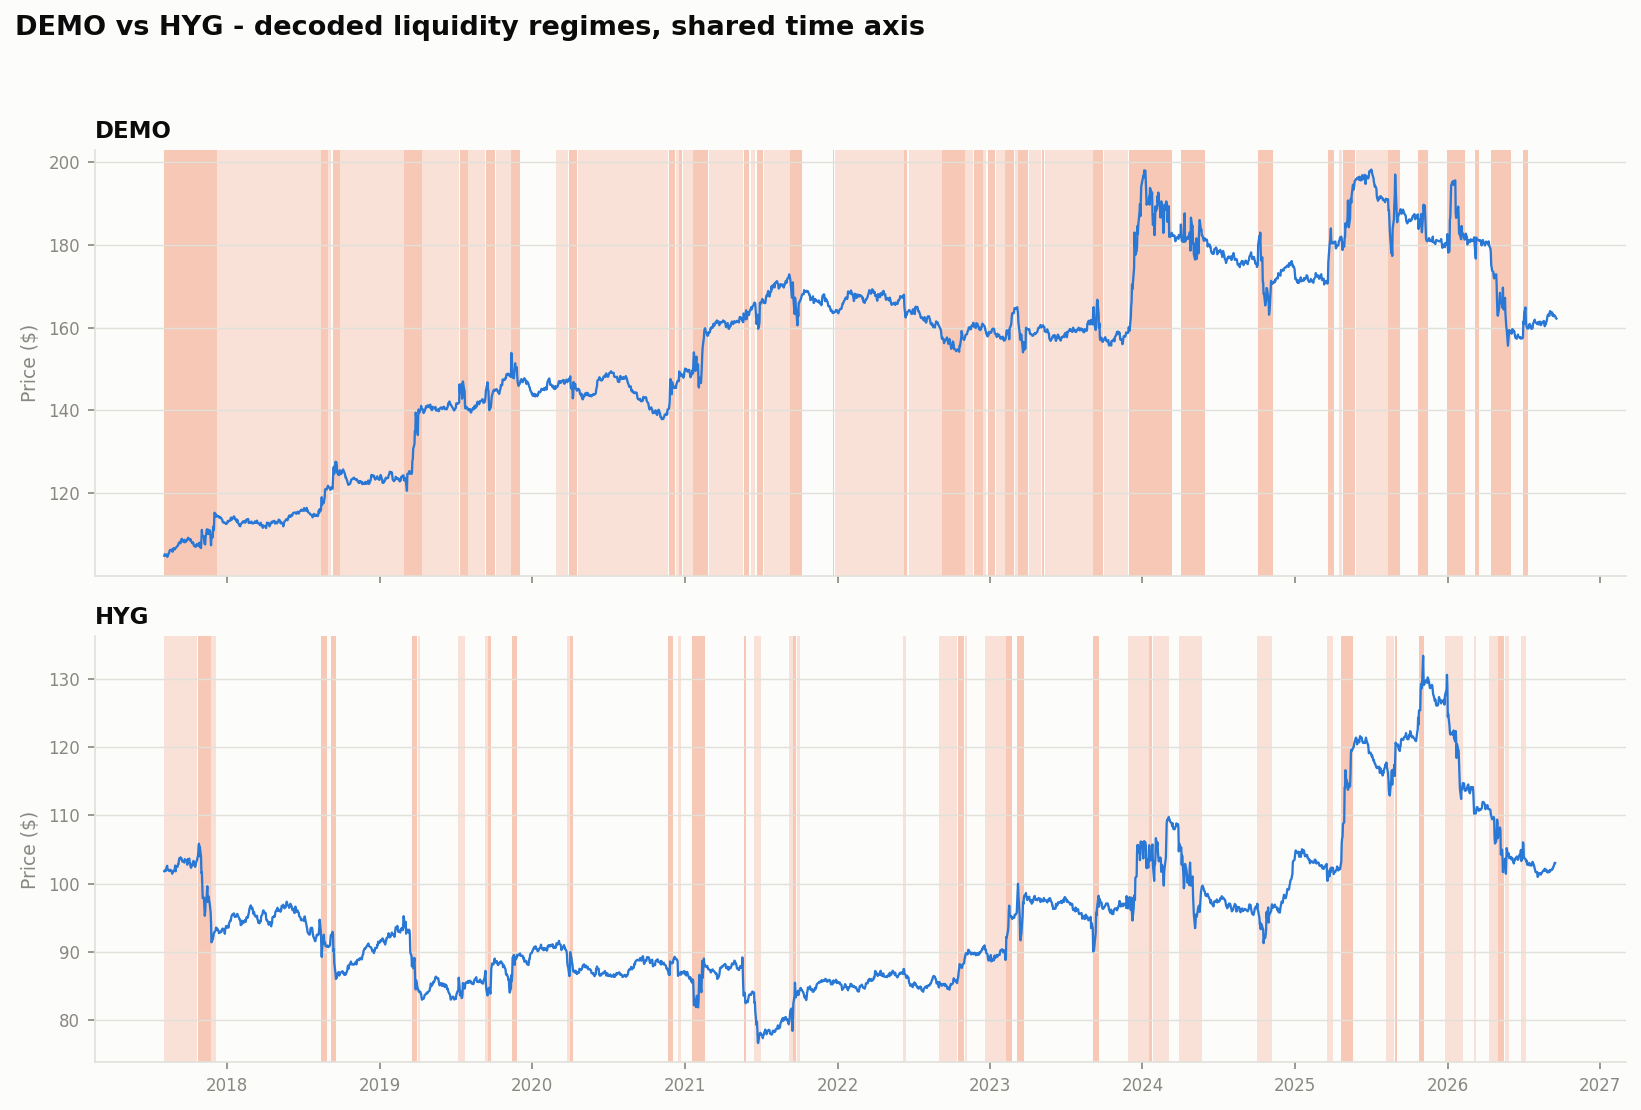

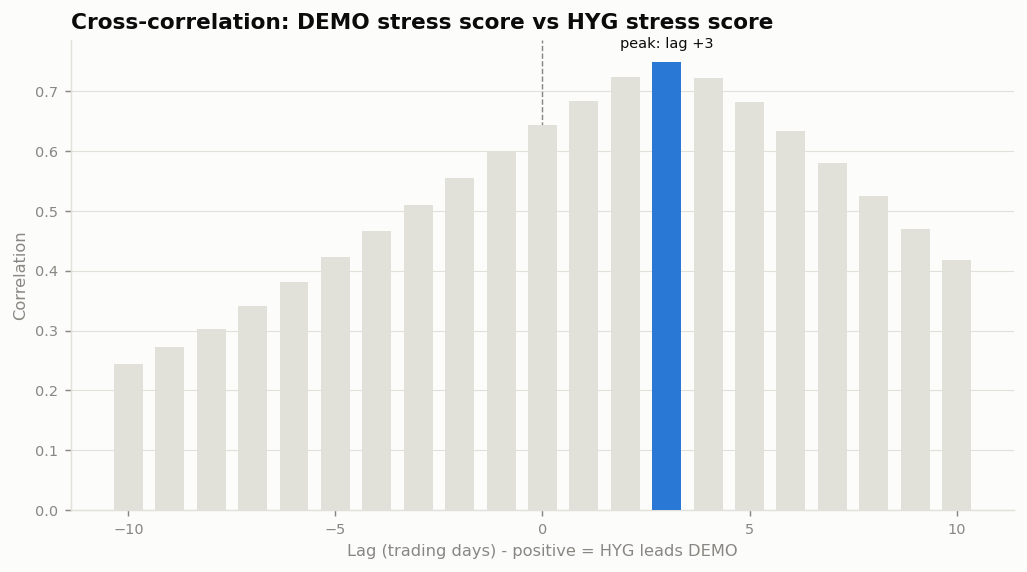

In [19]:
# --- NEW chart: joint two-panel price/regime comparison ------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.5), dpi=150, sharex=True)
fig.patch.set_facecolor(SURFACE)

for ax, price_i, states_i, labels_i, k_i, name_i in [
    (ax1, price_aligned, states, labels, chosen_k, ticker_label),
    (ax2, result_2["price"], result_2["states"], result_2["labels"], result_2["chosen_k"], SECOND_TICKER),
]:
    ax.set_facecolor(SURFACE)
    max_state_i = k_i - 1
    groups_i = (states_i != states_i.shift()).cumsum()
    for _, seg in states_i.groupby(groups_i):
        s = seg.iloc[0]
        if s > 0:
            alpha = 0.35 * (s / max_state_i)
            ax.axvspan(seg.index[0], seg.index[-1], color=COLOR_SHOCK, alpha=alpha, lw=0)
    ax.plot(price_i.index, price_i.values, color=COLOR_PRICE, linewidth=1.1, zorder=3)
    ax.set_title(f"{name_i}", color=COLOR_INK, fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel("Price ($)", color=COLOR_AXIS, fontsize=9)
    ax.tick_params(colors=COLOR_AXIS, labelsize=8)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(COLOR_GRID)
    ax.grid(axis="y", color=COLOR_GRID, linewidth=0.7, zorder=0)

fig.suptitle(f"{ticker_label} vs {SECOND_TICKER} - decoded liquidity regimes, shared time axis",
             color=COLOR_INK, fontsize=13, fontweight="bold", x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- NEW chart: cross-correlation function profile ------------------------
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=130)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
colors_ccf = [COLOR_PRICE if lag == best_lag else COLOR_GRID for lag in ccf.index]
ax.bar(ccf.index, ccf.values, color=colors_ccf, width=0.7, zorder=3)
ax.axvline(0, color=COLOR_AXIS, linewidth=0.8, linestyle="--", zorder=2)
ax.annotate(f"peak: lag {best_lag:+d}", xy=(best_lag, ccf.loc[best_lag]),
            xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8, color=COLOR_INK)
ax.set_title(f"Cross-correlation: {ticker_label} stress score vs {SECOND_TICKER} stress score",
             color=COLOR_INK, fontsize=12, fontweight="bold", loc="left")
ax.set_xlabel(f"Lag (trading days) - positive = {SECOND_TICKER} leads {ticker_label}", color=COLOR_AXIS, fontsize=9)
ax.set_ylabel("Correlation", color=COLOR_AXIS, fontsize=9)
ax.tick_params(colors=COLOR_AXIS, labelsize=8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(COLOR_GRID)
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.6, zorder=0)
fig.tight_layout()
plt.show()

## 11. Conclusioni e limiti

**Risultato principale.** Il modello HMM riesce a segmentare oggettivamente
la storia di trading dell'ETF in fasi di liquidità distinte, senza soglie
scelte a mano: il numero di stati è scelto tramite BIC, e le feature che
non discriminano bene (es. `vol_z`) possono essere escluse su base
empirica. L'aggiunta della feature *reale* (premio/sconto rispetto al NAV)
non stravolge la segmentazione ottenuta con i soli proxy da OHLCV — un
segnale di robustezza del modello, non un artefatto delle feature proxy.

**Limiti.**

- Il decoding Viterbi è **full-sample e retrospettivo**: usa tutta la
  serie storica, quindi non è direttamente utilizzabile come segnale di
  trading live (per quello servirebbe un filtraggio solo-forward,
  aggiornato giorno per giorno con l'informazione disponibile fino a quel
  momento).
- Le feature "proxy" (Parkinson, Amihud) sono costruite da OHLCV
  giornaliero, non da dati di order book o bid-ask reali intraday — con
  accesso a TAQ/dati di mercato tick-by-tick (es. WRDS) si potrebbero
  costruire misure di liquidità più dirette (spread bid-ask effettivo,
  profondità).
- L'HMM assume emissioni Gaussiane condizionate allo stato ed una
  dinamica dei regimi Markoviana del prim'ordine: sono assunzioni
  semplificatrici, standard in letteratura, ma pur sempre assunzioni.
- Il filtro di persistenza minima è una scelta di design (soglia = 5
  giorni in questo notebook) — cambia la lettura "episodica" del regime ma
  non rifitta il modello.

**Possibili estensioni.** Costruire una versione a filtraggio solo-forward
per un uso come indicatore di rischio in tempo reale, oppure estendere il
confronto cross-ETF della Sezione 10 a un terzo segmento (es. EMB, debito
emergente) per verificare se la gerarchia di anticipazione osservata tra
investment grade e high yield si generalizza. La Sezione 9 già fornisce un
primo controllo fuori campione contro un calendario di stress storico noto,
mentre la Sezione 10 mostra come lo stesso pipeline si estenda a un secondo
ETF per un'analisi di lead/lag tra segmenti di credito.